In [ ]:
# ============================================================
# CELDA DE INICIO — Ejecutar siempre la primera
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Rutas
BASE    = '/content/drive/MyDrive/TFG_EMT'
GTFS    = BASE + '/01_datos_planificados/gtfs_emt'
OFERTA  = BASE + '/02_oferta_real'
DEMANDA = BASE + '/03_demanda_viajeros'
COMPL   = BASE + '/04_datos_complementarios'
OUTPUT  = BASE + '/05_notebooks'

# Colores y configuración de gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

colores_lineas = {
    'Línea 27': '#0178BC',
    'Línea 34': '#E84B3A',
    'Línea C1': '#2ECC71'
}

orden_tramos = [
    '1_Punta_manana (7-9h)',
    '2_Mediodia (9-14h)',
    '3_Punta_tarde (14-16h)',
    '4_Tarde (16-20h)',
    '5_Noche (20-23h)'
]

etiquetas_tramos = {
    '1_Punta_manana (7-9h)':   'Punta\nmañana\n(7-9h)',
    '2_Mediodia (9-14h)':      'Mediodía\n(9-14h)',
    '3_Punta_tarde (14-16h)':  'Punta\ntarde\n(14-16h)',
    '4_Tarde (16-20h)':        'Tarde\n(16-20h)',
    '5_Noche (20-23h)':        'Noche\n(20-23h)'
}

print("✓ Drive montado y configuración cargada")
print(f"✓ Ficheros disponibles en OUTPUT:")
for f in sorted(os.listdir(OUTPUT)):
    print(f"    {f}")

In [ ]:
# ============================================================
# CELDA DE RECARGA — Recupera todas las variables procesadas
# ============================================================

# Cargamos los ficheros ya procesados desde Drive
indicadores_reales = pd.read_csv(f"{OUTPUT}/indicadores_reales_2025.csv")
demanda_mensual    = pd.read_csv(f"{OUTPUT}/demanda_mensual_2025.csv")
demanda_lineas     = pd.read_csv(f"{OUTPUT}/demanda_filtrada_2025.csv")
oferta_analisis    = pd.read_csv(f"{OUTPUT}/oferta_filtrada_2025.csv")
tabla_resumen      = pd.read_csv(f"{OUTPUT}/tabla_resumen_indicadores_LA.csv")

print("✓ Datos recargados correctamente:")
print(f"  indicadores_reales:  {len(indicadores_reales)} filas")
print(f"  demanda_mensual:     {len(demanda_mensual)} filas")
print(f"  demanda_lineas:      {len(demanda_lineas):,} filas")
print(f"  oferta_analisis:     {len(oferta_analisis):,} filas")
print(f"  tabla_resumen:       {len(tabla_resumen)} filas")

In [2]:
# Montamos Google Drive para acceder a los ficheros
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import os

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [5]:
# Ruta base del proyecto en Drive
# Ajusta esta ruta si tu carpeta TFG_EMT está en una ubicación diferente
BASE = '/content/drive/MyDrive/TFG_EMT'

GTFS    = BASE + '/01_datos_planificados/gtfs_emt'
OFERTA  = BASE + '/02_oferta_real'
DEMANDA = BASE + '/03_demanda_viajeros'
COMPL   = BASE + '/04_datos_complementarios'

print("Rutas definidas:")
print(f"  GTFS:    {GTFS}")
print(f"  Oferta:  {OFERTA}")
print(f"  Demanda: {DEMANDA}")
print(f"  Compl.:  {COMPL}")

Rutas definidas:
  GTFS:    /content/drive/MyDrive/TFG_EMT/01_datos_planificados/gtfs_emt
  Oferta:  /content/drive/MyDrive/TFG_EMT/02_oferta_real
  Demanda: /content/drive/MyDrive/TFG_EMT/03_demanda_viajeros
  Compl.:  /content/drive/MyDrive/TFG_EMT/04_datos_complementarios


In [6]:
# Comprobamos que todos los ficheros esperados están presentes
ficheros_gtfs = [
    'agency.txt', 'routes.txt', 'trips.txt', 'stop_times.txt',
    'stops.txt', 'calendar.txt', 'calendar_dates.txt',
    'frequencies.txt', 'shapes.txt'
]

print("=== FICHEROS GTFS ===")
for f in ficheros_gtfs:
    ruta = os.path.join(GTFS, f)
    estado = "✓ OK" if os.path.exists(ruta) else "✗ NO ENCONTRADO"
    print(f"  {estado}  {f}")

print("\n=== FICHEROS OFERTA REAL ===")
for f in sorted(os.listdir(OFERTA)):
    print(f"  ✓ OK  {f}")

print("\n=== DEMANDA VIAJEROS ===")
for f in os.listdir(DEMANDA):
    print(f"  ✓ OK  {f}")

print("\n=== DATOS COMPLEMENTARIOS ===")
for f in os.listdir(COMPL):
    print(f"  ✓ OK  {f}")

=== FICHEROS GTFS ===
  ✓ OK  agency.txt
  ✓ OK  routes.txt
  ✓ OK  trips.txt
  ✓ OK  stop_times.txt
  ✓ OK  stops.txt
  ✓ OK  calendar.txt
  ✓ OK  calendar_dates.txt
  ✓ OK  frequencies.txt
  ✓ OK  shapes.txt

=== FICHEROS OFERTA REAL ===
  ✓ OK  202501ccr.csv
  ✓ OK  202502ccr.csv
  ✓ OK  202503ccr.csv
  ✓ OK  202504ccr.csv
  ✓ OK  202505ccr.csv
  ✓ OK  202506ccr.csv
  ✓ OK  202507ccr.csv
  ✓ OK  202508ccr.csv
  ✓ OK  202509ccr.csv
  ✓ OK  202511ccr.csv
  ✓ OK  202512ccr.csv

=== DEMANDA VIAJEROS ===
  ✓ OK  demandadialinea_2025.csv

=== DATOS COMPLEMENTARIOS ===
  ✓ OK  paradas_emt.csv
  ✓ OK  lineas_emt.csv
  ✓ OK  calendario_operacion.csv


In [7]:
# Cargamos y exploramos cada fichero GTFS relevante

print("=" * 50)
print("ROUTES.TXT")
print("=" * 50)
routes = pd.read_csv(f"{GTFS}/routes.txt")
print(f"Filas: {len(routes)} | Columnas: {list(routes.columns)}")
print(routes.head(3))

print("\n" + "=" * 50)
print("TRIPS.TXT")
print("=" * 50)
trips = pd.read_csv(f"{GTFS}/trips.txt")
print(f"Filas: {len(trips)} | Columnas: {list(trips.columns)}")
print(trips.head(3))

print("\n" + "=" * 50)
print("STOP_TIMES.TXT")
print("=" * 50)
stop_times = pd.read_csv(f"{GTFS}/stop_times.txt", nrows=5)
print(f"Columnas: {list(stop_times.columns)}")
print(stop_times.head(3))

print("\n" + "=" * 50)
print("FREQUENCIES.TXT")
print("=" * 50)
try:
    frequencies = pd.read_csv(f"{GTFS}/frequencies.txt")
    print(f"Filas: {len(frequencies)} | Columnas: {list(frequencies.columns)}")
    print(frequencies.head(3))
except:
    print("El fichero frequencies.txt está vacío o no tiene datos")

print("\n" + "=" * 50)
print("CALENDAR.TXT")
print("=" * 50)
calendar = pd.read_csv(f"{GTFS}/calendar.txt")
print(f"Filas: {len(calendar)} | Columnas: {list(calendar.columns)}")
print(calendar.head(3))

ROUTES.TXT
Filas: 236 | Columnas: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color']
   route_id agency_id route_short_name  \
0         1       EMT                1   
1         2       EMT                2   
2         3       EMT                3   

                                    route_long_name  route_desc  route_type  \
0                 Plaza de Cristo Rey - Prosperidad         NaN           3   
1  Plaza de Manuel Becerra - Avenida Reina Victoria         NaN           3   
2             Puerta de Toledo - Plaza de San Amaro         NaN           3   

                                          route_url route_color  \
0  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=1      0178BC   
1  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=2      0178BC   
2  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=3      0178BC   

  route_text_color  
0           FFFFFF  
1           FFFFFF  
2      

In [8]:
# Localizamos nuestras tres líneas de estudio en el fichero de rutas
print("Buscando líneas 27, 34 y C1 en routes.txt...\n")

# Mostramos todas las columnas disponibles primero
print("Columnas disponibles en routes.txt:")
print(routes.columns.tolist())
print()

# Buscamos las líneas por nombre corto
lineas_buscar = ['27', '34', 'C1', 'c1']

mascara = routes['route_short_name'].astype(str).isin(lineas_buscar)
lineas_encontradas = routes[mascara]

print(f"Líneas encontradas: {len(lineas_encontradas)}")
print(lineas_encontradas)

Buscando líneas 27, 34 y C1 en routes.txt...

Columnas disponibles en routes.txt:
['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type', 'route_url', 'route_color', 'route_text_color']

Líneas encontradas: 3
    route_id agency_id route_short_name  \
25        27       EMT               27   
32        34       EMT               34   
66        68       EMT               C1   

                                route_long_name  route_desc  route_type  \
25  Glorieta de Embajadores - Plaza de Castilla         NaN           3   
32               Plaza de Cibeles - las Aguilas         NaN           3   
66                                Circular 1 -          NaN           3   

                                            route_url route_color  \
25  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=27      0178BC   
32  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=34      0178BC   
66  https://www.emtmadrid.es/EMTBUS/Mi-linea?linea=C1      0178BC   

   

In [9]:
# Cargamos uno de los CSV de oferta real para entender su estructura
# Usamos enero 2025 como ejemplo
ficheros_oferta = sorted(os.listdir(OFERTA))
primer_fichero = ficheros_oferta[0]

print(f"Explorando: {primer_fichero}\n")
oferta_ene = pd.read_csv(f"{OFERTA}/{primer_fichero}", sep=None, engine='python')

print(f"Filas: {len(oferta_ene)}")
print(f"Columnas: {list(oferta_ene.columns)}")
print("\nPrimeras filas:")
print(oferta_ene.head(5))
print("\nTipos de datos:")
print(oferta_ene.dtypes)

Explorando: 202501ccr.csv

Filas: 126730
Columnas: ['Linea', 'FECHASER', 'TIPODIAMO', 'CodFranja', 'NumCCReal']

Primeras filas:
   Linea             FECHASER TIPODIAMO  CodFranja  NumCCReal
0      1  2025-01-01 00:00:00        FE          7          2
1      1  2025-01-01 00:00:00        FE          8          3
2      1  2025-01-01 00:00:00        FE          9          3
3      1  2025-01-01 00:00:00        FE         10          4
4      1  2025-01-01 00:00:00        FE         11          4

Tipos de datos:
Linea         int64
FECHASER     object
TIPODIAMO    object
CodFranja     int64
NumCCReal     int64
dtype: object


In [10]:
# Exploramos el fichero de demanda diaria
fichero_demanda = os.listdir(DEMANDA)[0]
print(f"Explorando: {fichero_demanda}\n")

demanda = pd.read_csv(f"{DEMANDA}/{fichero_demanda}", sep=None, engine='python')

print(f"Filas: {len(demanda)}")
print(f"Columnas: {list(demanda.columns)}")
print("\nPrimeras filas:")
print(demanda.head(5))
print("\nTipos de datos:")
print(demanda.dtypes)

Explorando: demandadialinea_2025.csv

Filas: 83169
Columnas: ['\ufeffFecha', 'Linea', 'TotalViajeros']

Primeras filas:
       ﻿Fecha  Linea  TotalViajeros
0  2025-01-01      1           2359
1  2025-01-01      2           3346
2  2025-01-01      3           2446
3  2025-01-01      4           1980
4  2025-01-01      5           1808

Tipos de datos:
﻿Fecha           object
Linea             int64
TotalViajeros     int64
dtype: object


In [12]:
# Análisis de la operación real — Oferta de autobuses 2025

In [14]:
# Cargar y unir todos los CSV de oferta real

# Cargamos todos los ficheros mensuales y los concatenamos
ficheros = sorted([f for f in os.listdir(OFERTA) if f.endswith('.csv')])

print("Ficheros a cargar:")
for f in ficheros:
    print(f"  {f}")

lista_dfs = []
for f in ficheros:
    df = pd.read_csv(f"{OFERTA}/{f}", sep=';', encoding='latin1')
    lista_dfs.append(df)

oferta = pd.concat(lista_dfs, ignore_index=True)

print(f"\nTotal de registros cargados: {len(oferta):,}")
print(f"Columnas: {oferta.columns.tolist()}")
print(f"\nPrimeras filas:")
print(oferta.head(5))

Ficheros a cargar:
  202501ccr.csv
  202502ccr.csv
  202503ccr.csv
  202504ccr.csv
  202505ccr.csv
  202506ccr.csv
  202507ccr.csv
  202508ccr.csv
  202509ccr.csv
  202511ccr.csv
  202512ccr.csv

Total de registros cargados: 1,336,709
Columnas: ['Linea', 'FECHASER', 'TIPODIAMO', 'CodFranja', 'NumCCReal']

Primeras filas:
   Linea             FECHASER TIPODIAMO  CodFranja  NumCCReal
0      1  2025-01-01 00:00:00        FE          7          2
1      1  2025-01-01 00:00:00        FE          8          3
2      1  2025-01-01 00:00:00        FE          9          3
3      1  2025-01-01 00:00:00        FE         10          4
4      1  2025-01-01 00:00:00        FE         11          4


In [15]:
#Inspección inicial y limpieza
print("Tipos de datos:")
print(oferta.dtypes)

print(f"\nValores únicos en TIPODIAMO: {oferta['TIPODIAMO'].unique()}")
print(f"Valores únicos en CodFranja:  {sorted(oferta['CodFranja'].unique())}")
print(f"Rango de fechas: {oferta['FECHASER'].min()} → {oferta['FECHASER'].max()}")
print(f"Líneas únicas:   {oferta['Linea'].nunique()} líneas")

# Convertimos fecha a datetime
oferta['FECHASER'] = pd.to_datetime(oferta['FECHASER'])

# Extraemos mes
oferta['mes'] = oferta['FECHASER'].dt.month
oferta['anio'] = oferta['FECHASER'].dt.year

print(f"\nRegistros por mes:")
print(oferta.groupby('mes').size().reset_index(name='registros'))

Tipos de datos:
Linea         int64
FECHASER     object
TIPODIAMO    object
CodFranja     int64
NumCCReal     int64
dtype: object

Valores únicos en TIPODIAMO: ['FE' 'LA' 'SA']
Valores únicos en CodFranja:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]
Rango de fechas: 2025-01-01 00:00:00 → 2025-12-31 00:00:00
Líneas únicas:   255 líneas

Registros por mes:
    mes  registros
0     1     126730
1     2     115936
2     3     128365
3     4     123434
4     5     127517
5     6     118208
6     7     121697
7     8     119789
8     9     118661
9    11     117

In [16]:
# Identificar cómo aparece C1 en los datos reales
print("Valores únicos de Linea (todos):")
print(sorted(oferta['Linea'].astype(str).unique()))

Valores únicos de Linea (todos):
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116', '118', '119', '12', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '14', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '155', '156', '158', '159', '16', '160', '161', '162', '163', '164', '165', '166', '167', '17', '170', '171', '172', '173', '174', '175', '176', '177', '178', '179', '18', '180', '19', '2', '20', '200', '203', '21', '210', '215', '22', '23', '24', '247', '25', '26', '27', '28', '29', '3', '30', '31', '310', '32', '33', '34', '35', '36', '361', '362', '363', '37', '372', '38', '39', '4', '40', '401', '402', '403', '404', '405', '41', '42', '43', '44', '45', '451', '452', '453', '454', '455', '456', '46', '47', '48', '481', '49', '5', '50', '501', '502', '

In [17]:
# Filtrar las líneas de estudio

# Ajusta según lo visto en la Celda Anterior
# Este filtro cubre las posibles codificaciones de las tres líneas
mascara = oferta['Linea'].astype(str).isin(['27', '34', 'C1', '68', 'c1'])
oferta_lineas = oferta[mascara].copy()

# Asignamos nombre legible
def asignar_nombre(linea):
    linea = str(linea)
    if linea == '27':
        return 'Línea 27'
    elif linea == '34':
        return 'Línea 34'
    elif linea in ['68', 'C1', 'c1']:
        return 'Línea C1'
    return linea

oferta_lineas['nombre_linea'] = oferta_lineas['Linea'].apply(asignar_nombre)

print(f"Registros filtrados: {len(oferta_lineas):,}")
print()
print(oferta_lineas.groupby(['nombre_linea', 'TIPODIAMO'])
      .size()
      .reset_index(name='registros'))

Registros filtrados: 20,029

  nombre_linea TIPODIAMO  registros
0     Línea 27        FE       1133
1     Línea 27        LA       4572
2     Línea 27        SA        921
3     Línea 34        FE       1148
4     Línea 34        LA       4670
5     Línea 34        SA        950
6     Línea C1        FE       1114
7     Línea C1        LA       4574
8     Línea C1        SA        947


In [18]:
#Verificar códigos de franja Horaria

print("Códigos de franja horaria disponibles:")
print(sorted(oferta_lineas['CodFranja'].unique()))

print("\nEjemplo de registros por franja:")
print(oferta_lineas.groupby('CodFranja')['NumCCReal']
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={'NumCCReal': 'media_autobuses'}))

Códigos de franja horaria disponibles:
[np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34)]

Ejemplo de registros por franja:
    CodFranja  media_autobuses
0           0             0.00
1           4             0.00
2           5             5.64
3           6            11.50
4           7            15.34
5           8            16.59
6           9            17.08
7          10            15.33
8          11            14.42
9          12            14.58
10         13            15.15
11         14            15.15
12         15            14.95
13         16            14.94
14         17       

In [19]:
#Definir tramos horarios (corregida)

# Los códigos de franja representan la hora del día (0-34)
# Solo analizamos las franjas con servicio real y dentro del horario del estudio

mapa_franjas = {
    7:  '1_Punta_manana (7-9h)',
    8:  '1_Punta_manana (7-9h)',
    9:  '2_Mediodia (9-14h)',
    10: '2_Mediodia (9-14h)',
    11: '2_Mediodia (9-14h)',
    12: '2_Mediodia (9-14h)',
    13: '2_Mediodia (9-14h)',
    14: '3_Punta_tarde (14-16h)',
    15: '3_Punta_tarde (14-16h)',
    16: '4_Tarde (16-20h)',
    17: '4_Tarde (16-20h)',
    18: '4_Tarde (16-20h)',
    19: '4_Tarde (16-20h)',
    20: '5_Noche (20-23h)',
    21: '5_Noche (20-23h)',
    22: '5_Noche (20-23h)',
}

# Aplicamos el mapa
oferta_lineas['tramo_horario'] = oferta_lineas['CodFranja'].map(mapa_franjas)

# Filtramos solo tramos dentro del análisis
oferta_analisis = oferta_lineas[oferta_lineas['tramo_horario'].notna()].copy()

print(f"Registros dentro del análisis: {len(oferta_analisis):,}")
print(f"Registros fuera del análisis:  {len(oferta_lineas) - len(oferta_analisis):,}")
print()
print("Distribución por tramo horario y media de autobuses:")
print(oferta_analisis.groupby('tramo_horario')['NumCCReal']
      .agg(registros='count', media_autobuses='mean')
      .round(2)
      .reset_index()
      .sort_values('tramo_horario')
      .to_string(index=False))

Registros dentro del análisis: 16,025
Registros fuera del análisis:  4,004

Distribución por tramo horario y media de autobuses:
         tramo_horario  registros  media_autobuses
 1_Punta_manana (7-9h)       2002            15.96
    2_Mediodia (9-14h)       5008            15.31
3_Punta_tarde (14-16h)       2004            15.05
      4_Tarde (16-20h)       4008            15.33
      5_Noche (20-23h)       3003            12.23


In [20]:
#Calcular indicadores de eficiencia operativa

# Calculamos los indicadores estadísticos sobre NumCCReal
# agrupando por línea, tipo de día y tramo horario
indicadores_reales = oferta_analisis.groupby(
    ['nombre_linea', 'TIPODIAMO', 'tramo_horario']
)['NumCCReal'].agg(
    media='mean',
    desviacion_tipica='std',
    minimo='min',
    maximo='max',
    num_observaciones='count'
).reset_index()

# Coeficiente de variación
indicadores_reales['cv'] = (
    indicadores_reales['desviacion_tipica'] /
    indicadores_reales['media'] * 100
).round(2)

# Redondeamos
indicadores_reales['media'] = indicadores_reales['media'].round(2)
indicadores_reales['desviacion_tipica'] = (
    indicadores_reales['desviacion_tipica'].round(2)
)

print(f"Indicadores calculados: {len(indicadores_reales)} combinaciones")
print()
print(indicadores_reales.head(10).to_string(index=False))

Indicadores calculados: 45 combinaciones

nombre_linea TIPODIAMO          tramo_horario  media  desviacion_tipica  minimo  maximo  num_observaciones    cv
    Línea 27        FE  1_Punta_manana (7-9h)   4.32               0.65       3       5                122 14.96
    Línea 27        FE     2_Mediodia (9-14h)   6.58               0.84       4       8                308 12.76
    Línea 27        FE 3_Punta_tarde (14-16h)   6.27               0.89       4       8                124 14.26
    Línea 27        FE       4_Tarde (16-20h)   6.20               0.91       4       8                248 14.65
    Línea 27        FE       5_Noche (20-23h)   5.98               0.93       4       8                186 15.55
    Línea 27        LA  1_Punta_manana (7-9h)  21.65               3.64      11      24                452 16.83
    Línea 27        LA     2_Mediodia (9-14h)  16.26               3.80       8      24               1130 23.36
    Línea 27        LA 3_Punta_tarde (14-16h)  14.93  

In [22]:
#Clasificar nivel de servicio


def clasificar_nivel(cv):
    if pd.isna(cv):
        return 'Sin datos'
    elif cv < 20:
        return 'Excelente (CV < 20%)'
    elif cv < 40:
        return 'Bueno (20% ≤ CV < 40%)'
    elif cv < 60:
        return 'Regular (40% ≤ CV < 60%)'
    elif cv < 80:
        return 'Deficiente (60% ≤ CV < 80%)'
    else:
        return 'Muy deficiente (CV ≥ 80%)'

indicadores_reales['nivel_servicio'] = (
    indicadores_reales['cv'].apply(clasificar_nivel)
)

# Resumen para días laborables
resumen_LA = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
].sort_values(['nombre_linea', 'tramo_horario'])

print("INDICADORES REALES — DÍAS LABORABLES")
print("=" * 80)
for linea in ['Línea 27', 'Línea 34', 'Línea C1']:
    print(f"\n{linea}:")
    subset = resumen_LA[resumen_LA['nombre_linea'] == linea]
    print(subset[['tramo_horario', 'media', 'desviacion_tipica',
                  'cv', 'num_observaciones',
                  'nivel_servicio']].to_string(index=False))

INDICADORES REALES — DÍAS LABORABLES

Línea 27:
         tramo_horario  media  desviacion_tipica    cv  num_observaciones         nivel_servicio
 1_Punta_manana (7-9h)  21.65               3.64 16.83                452   Excelente (CV < 20%)
    2_Mediodia (9-14h)  16.26               3.80 23.36               1130 Bueno (20% ≤ CV < 40%)
3_Punta_tarde (14-16h)  14.93               2.15 14.40                452   Excelente (CV < 20%)
      4_Tarde (16-20h)  14.83               2.38 16.06                904   Excelente (CV < 20%)
      5_Noche (20-23h)  11.69               3.12 26.66                677 Bueno (20% ≤ CV < 40%)

Línea 34:
         tramo_horario  media  desviacion_tipica    cv  num_observaciones         nivel_servicio
 1_Punta_manana (7-9h)  20.50               3.22 15.71                452   Excelente (CV < 20%)
    2_Mediodia (9-14h)  19.28               2.96 15.38               1130   Excelente (CV < 20%)
3_Punta_tarde (14-16h)  19.67               2.68 13.62              

In [24]:
# Guardamos datos

import os

BASE   = '/content/drive/MyDrive/TFG_EMT'
OUTPUT = BASE + '/05_notebooks'

os.makedirs(OUTPUT, exist_ok=True)

indicadores_reales.to_csv(
    f"{OUTPUT}/indicadores_reales_2025.csv",
    index=False,
    encoding='utf-8-sig'
)

oferta_analisis.to_csv(
    f"{OUTPUT}/oferta_filtrada_2025.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Ficheros guardados correctamente:")
print(f"  indicadores_reales_2025.csv  →  {len(indicadores_reales)} filas")
print(f"  oferta_filtrada_2025.csv     →  {len(oferta_analisis):,} filas")

Ficheros guardados correctamente:
  indicadores_reales_2025.csv  →  45 filas
  oferta_filtrada_2025.csv     →  16,025 filas


In [21]:
# PARTE 3 : VISUALIZACIONES

In [25]:
# Librerías de visualizacion

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

# Colores por línea
colores_lineas = {
    'Línea 27': '#0178BC',
    'Línea 34': '#E84B3A',
    'Línea C1': '#2ECC71'
}

# Orden de tramos horarios
orden_tramos = [
    '1_Punta_manana (7-9h)',
    '2_Mediodia (9-14h)',
    '3_Punta_tarde (14-16h)',
    '4_Tarde (16-20h)',
    '5_Noche (20-23h)'
]

# Etiquetas legibles para los tramos
etiquetas_tramos = {
    '1_Punta_manana (7-9h)':   'Punta\nmañana\n(7-9h)',
    '2_Mediodia (9-14h)':      'Mediodía\n(9-14h)',
    '3_Punta_tarde (14-16h)':  'Punta\ntarde\n(14-16h)',
    '4_Tarde (16-20h)':        'Tarde\n(16-20h)',
    '5_Noche (20-23h)':        'Noche\n(20-23h)'
}

print("Librerías de visualización cargadas correctamente")

Librerías de visualización cargadas correctamente


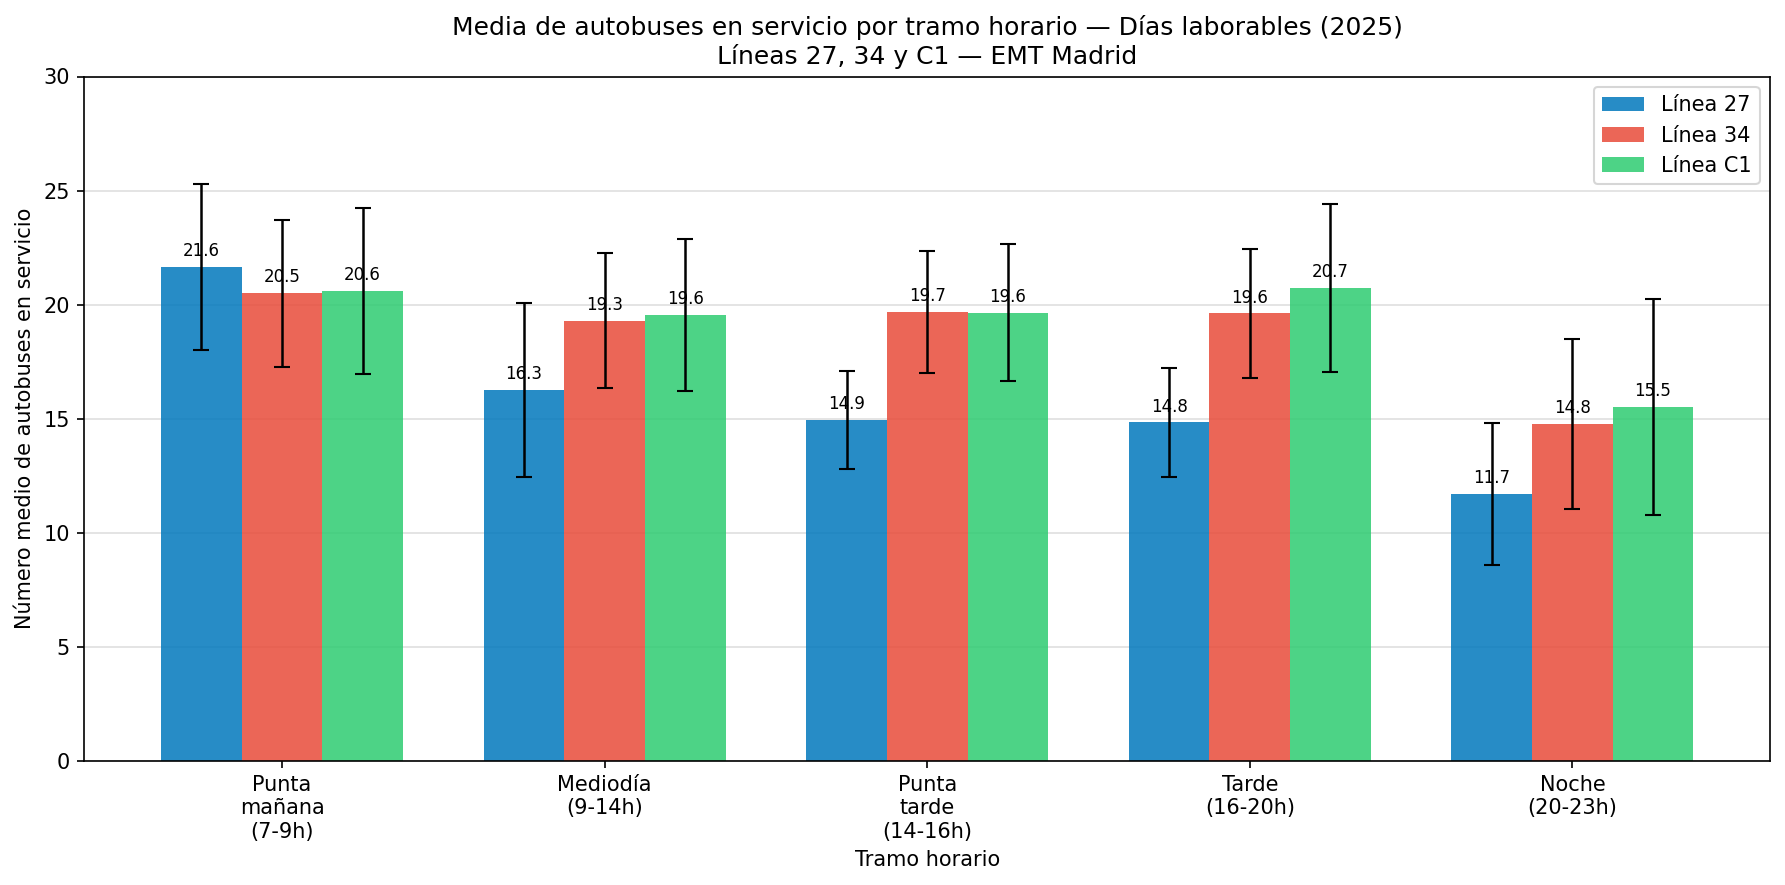

Gráfico 1 guardado


In [26]:
#  Gráfico 1: Media de autobuses por tramo horario (días laborables)

fig, ax = plt.subplots(figsize=(12, 6))

resumen_LA = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
].copy()

x = range(len(orden_tramos))
ancho = 0.25
lineas = ['Línea 27', 'Línea 34', 'Línea C1']

for i, linea in enumerate(lineas):
    datos = resumen_LA[resumen_LA['nombre_linea'] == linea].set_index('tramo_horario')
    valores = [datos.loc[t, 'media'] if t in datos.index else 0
               for t in orden_tramos]
    errores = [datos.loc[t, 'desviacion_tipica'] if t in datos.index else 0
               for t in orden_tramos]

    barras = ax.bar(
        [xi + i * ancho for xi in x],
        valores,
        ancho,
        label=linea,
        color=colores_lineas[linea],
        alpha=0.85,
        yerr=errores,
        capsize=4,
        error_kw={'linewidth': 1.2}
    )

    # Etiquetas de valor sobre cada barra
    for barra, val in zip(barras, valores):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=8
        )

ax.set_xticks([xi + ancho for xi in x])
ax.set_xticklabels([etiquetas_tramos[t] for t in orden_tramos])
ax.set_xlabel('Tramo horario')
ax.set_ylabel('Número medio de autobuses en servicio')
ax.set_title('Media de autobuses en servicio por tramo horario — Días laborables (2025)\nLíneas 27, 34 y C1 — EMT Madrid')
ax.legend(loc='upper right')
ax.set_ylim(0, 30)
ax.grid(axis='y', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico1_media_autobuses_LA.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 1 guardado")

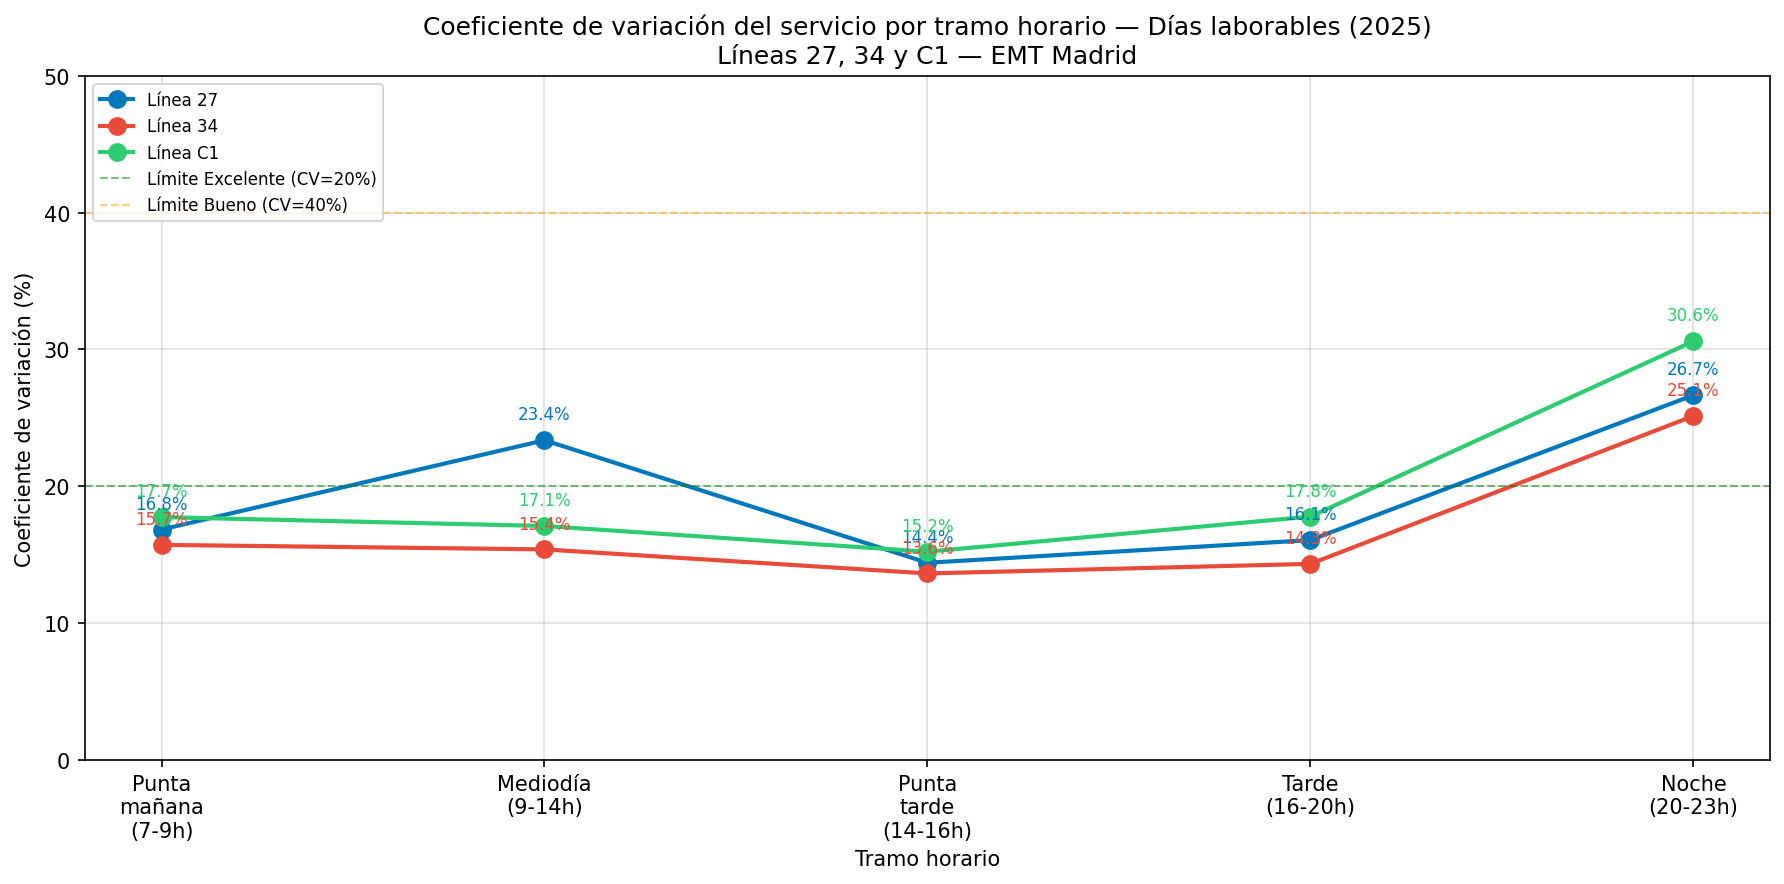

Gráfico 2 guardado


In [27]:
# Gráfico 2: Coeficiente de variación por tramo horario (días laborables)

fig, ax = plt.subplots(figsize=(12, 6))

for i, linea in enumerate(lineas):
    datos = resumen_LA[resumen_LA['nombre_linea'] == linea].set_index('tramo_horario')
    valores_cv = [datos.loc[t, 'cv'] if t in datos.index else 0
                  for t in orden_tramos]

    ax.plot(
        [etiquetas_tramos[t] for t in orden_tramos],
        valores_cv,
        marker='o',
        linewidth=2,
        markersize=8,
        label=linea,
        color=colores_lineas[linea]
    )

    # Etiquetas de valor
    for j, val in enumerate(valores_cv):
        ax.annotate(
            f'{val:.1f}%',
            (etiquetas_tramos[orden_tramos[j]], val),
            textcoords='offset points',
            xytext=(0, 10),
            ha='center',
            fontsize=8,
            color=colores_lineas[linea]
        )

# Líneas de referencia de niveles de servicio
ax.axhline(y=20, color='green', linestyle='--',
           alpha=0.5, linewidth=1, label='Límite Excelente (CV=20%)')
ax.axhline(y=40, color='orange', linestyle='--',
           alpha=0.5, linewidth=1, label='Límite Bueno (CV=40%)')

ax.set_xlabel('Tramo horario')
ax.set_ylabel('Coeficiente de variación (%)')
ax.set_title('Coeficiente de variación del servicio por tramo horario — Días laborables (2025)\nLíneas 27, 34 y C1 — EMT Madrid')
ax.legend(loc='upper left', fontsize=8)
ax.set_ylim(0, 50)
ax.grid(alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico2_cv_LA.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 2 guardado")

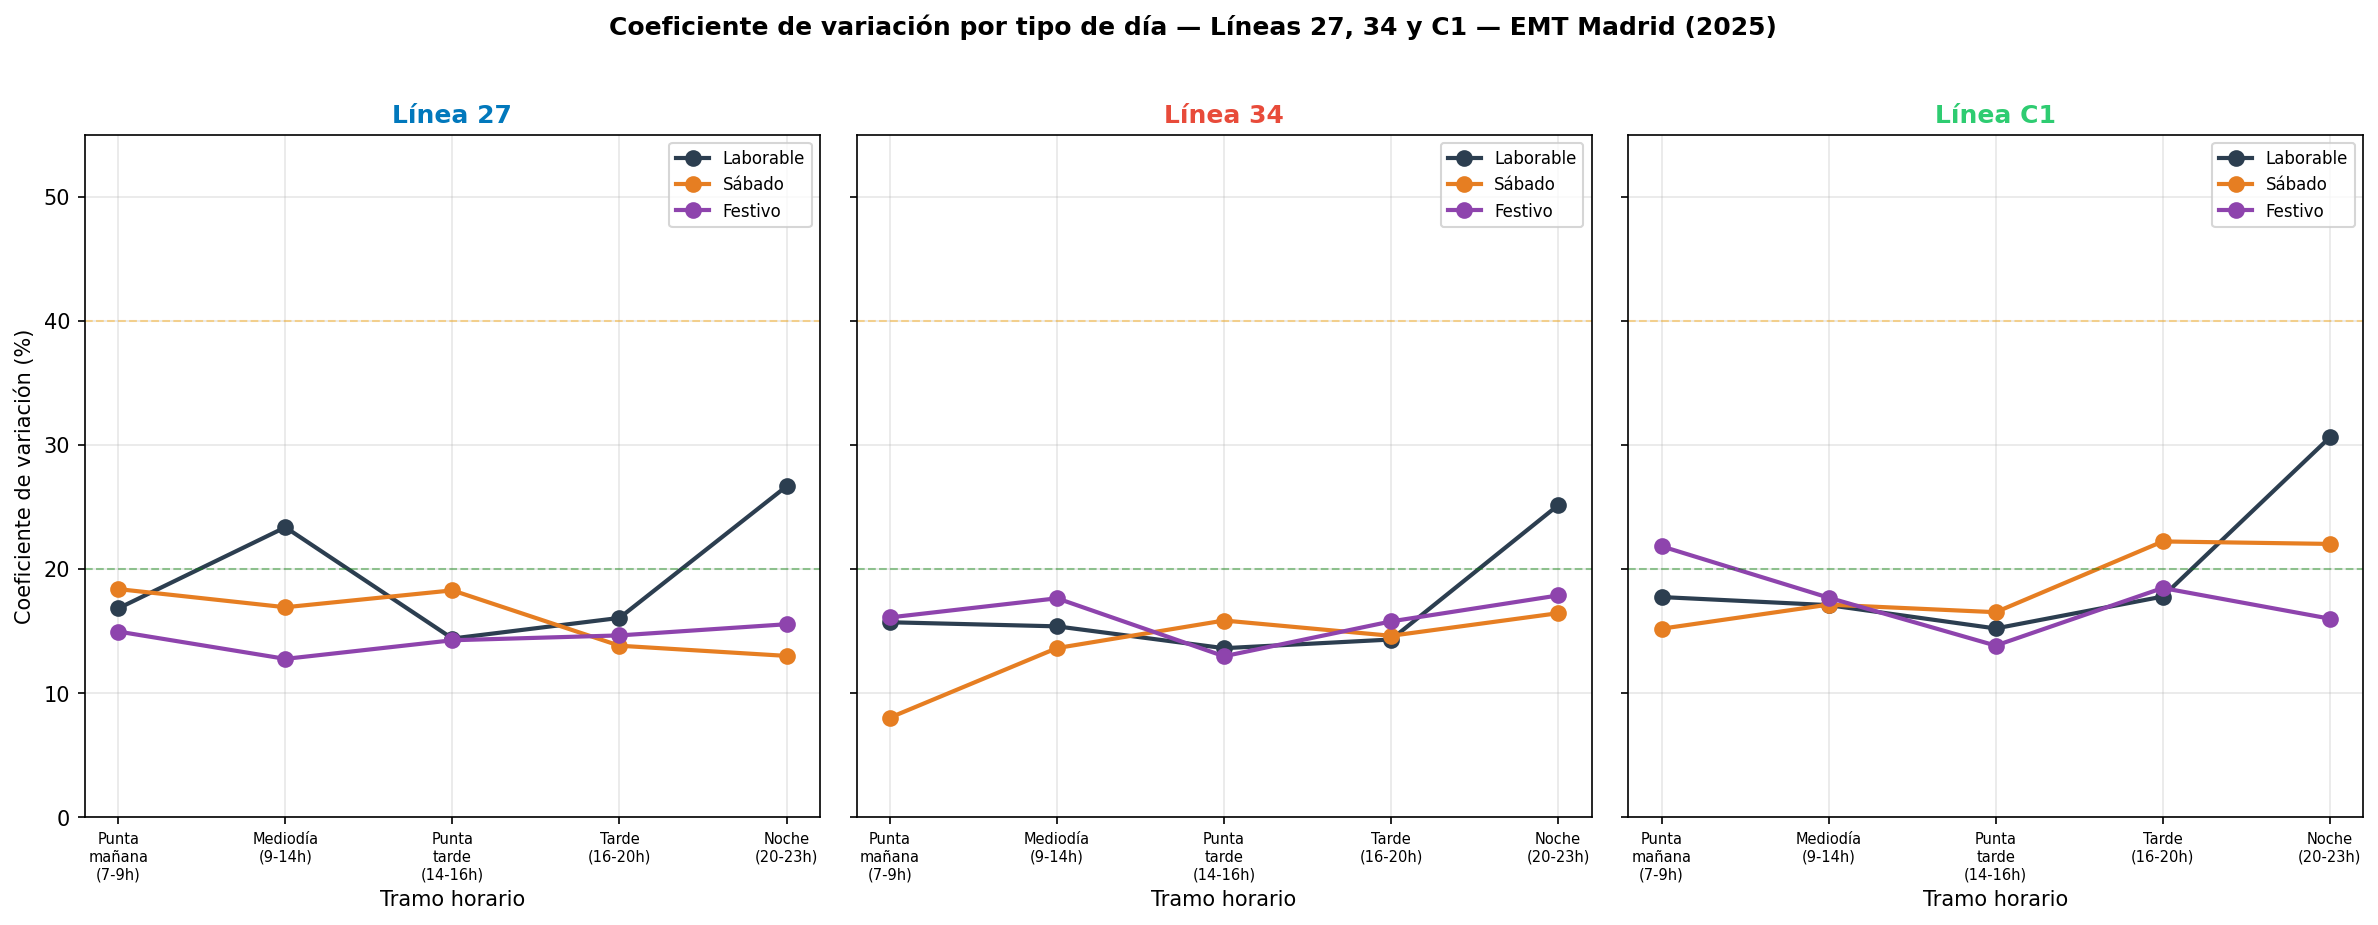

Gráfico 3 guardado


In [28]:
#  Gráfico 3: Comparativa entre tipos de día (CV por línea)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

tipos_dia = {'LA': 'Laborable', 'SA': 'Sábado', 'FE': 'Festivo'}
colores_dia = {'LA': '#2C3E50', 'SA': '#E67E22', 'FE': '#8E44AD'}

for idx, linea in enumerate(lineas):
    ax = axes[idx]
    datos_linea = indicadores_reales[
        indicadores_reales['nombre_linea'] == linea
    ]

    for tipo, etiqueta in tipos_dia.items():
        datos_tipo = datos_linea[
            datos_linea['TIPODIAMO'] == tipo
        ].set_index('tramo_horario')

        valores_cv = [datos_tipo.loc[t, 'cv'] if t in datos_tipo.index else None
                      for t in orden_tramos]

        ax.plot(
            [etiquetas_tramos[t] for t in orden_tramos],
            valores_cv,
            marker='o',
            linewidth=2,
            markersize=7,
            label=etiqueta,
            color=colores_dia[tipo]
        )

    ax.axhline(y=20, color='green', linestyle='--', alpha=0.4, linewidth=1)
    ax.axhline(y=40, color='orange', linestyle='--', alpha=0.4, linewidth=1)
    ax.set_title(linea, color=colores_lineas[linea], fontweight='bold')
    ax.set_xlabel('Tramo horario')
    ax.set_ylim(0, 55)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=7)

    if idx == 0:
        ax.set_ylabel('Coeficiente de variación (%)')

    ax.legend(fontsize=8)

fig.suptitle(
    'Coeficiente de variación por tipo de día — Líneas 27, 34 y C1 — EMT Madrid (2025)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico3_cv_por_tipo_dia.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 3 guardado")

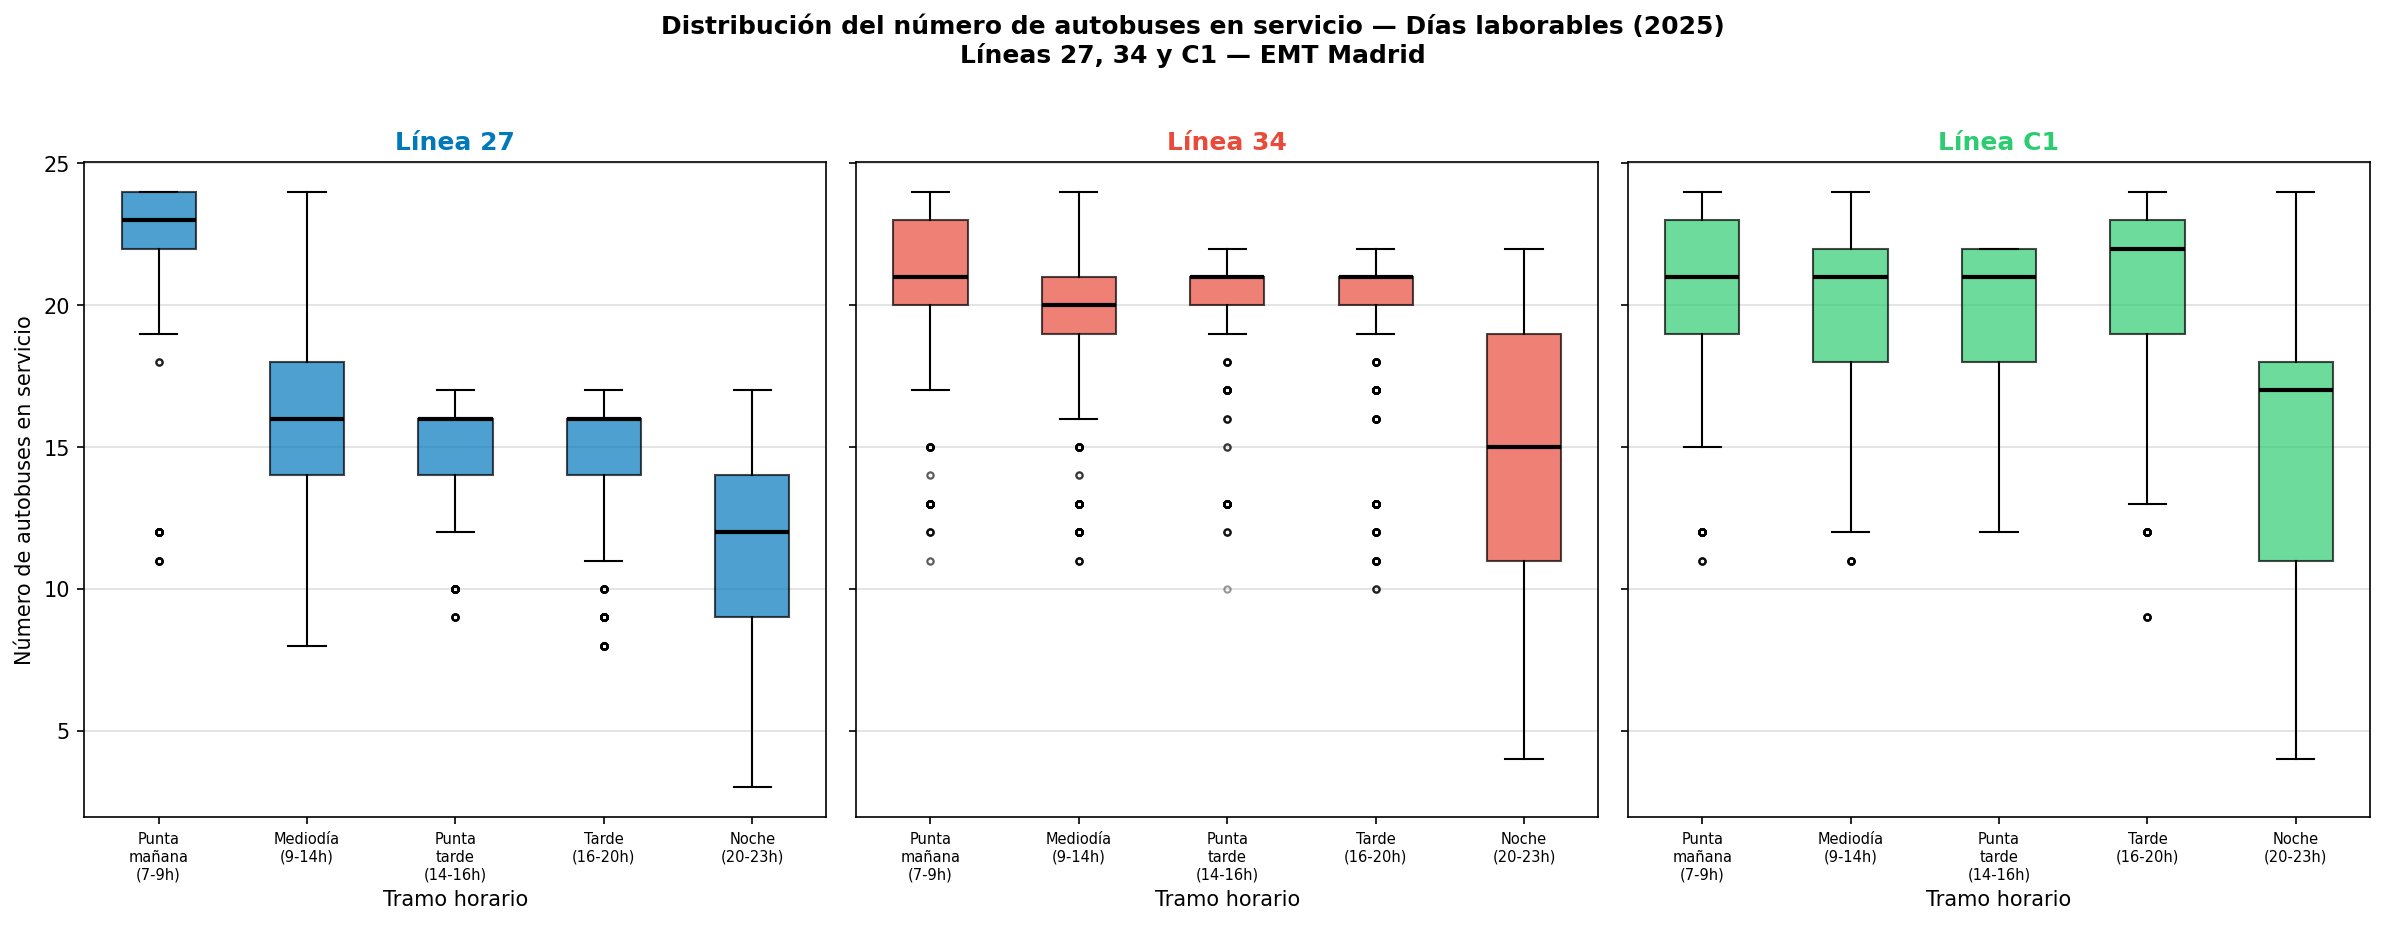

Gráfico 4 guardado


In [29]:
# Gráfico 4: Diagrama de caja (box plot) por línea — días laborables

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for idx, linea in enumerate(lineas):
    ax = axes[idx]

    datos_linea = oferta_analisis[
        (oferta_analisis['nombre_linea'] == linea) &
        (oferta_analisis['TIPODIAMO'] == 'LA')
    ]

    # Preparamos los datos por tramo horario
    datos_boxplot = [
        datos_linea[datos_linea['tramo_horario'] == t]['NumCCReal'].values
        for t in orden_tramos
    ]

    bp = ax.boxplot(
        datos_boxplot,
        patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )

    for patch in bp['boxes']:
        patch.set_facecolor(colores_lineas[linea])
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(orden_tramos) + 1))
    ax.set_xticklabels(
        [etiquetas_tramos[t] for t in orden_tramos],
        fontsize=7
    )
    ax.set_title(linea, color=colores_lineas[linea], fontweight='bold')
    ax.set_xlabel('Tramo horario')
    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel('Número de autobuses en servicio')

fig.suptitle(
    'Distribución del número de autobuses en servicio — Días laborables (2025)\nLíneas 27, 34 y C1 — EMT Madrid',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico4_boxplot_LA.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 4 guardado")

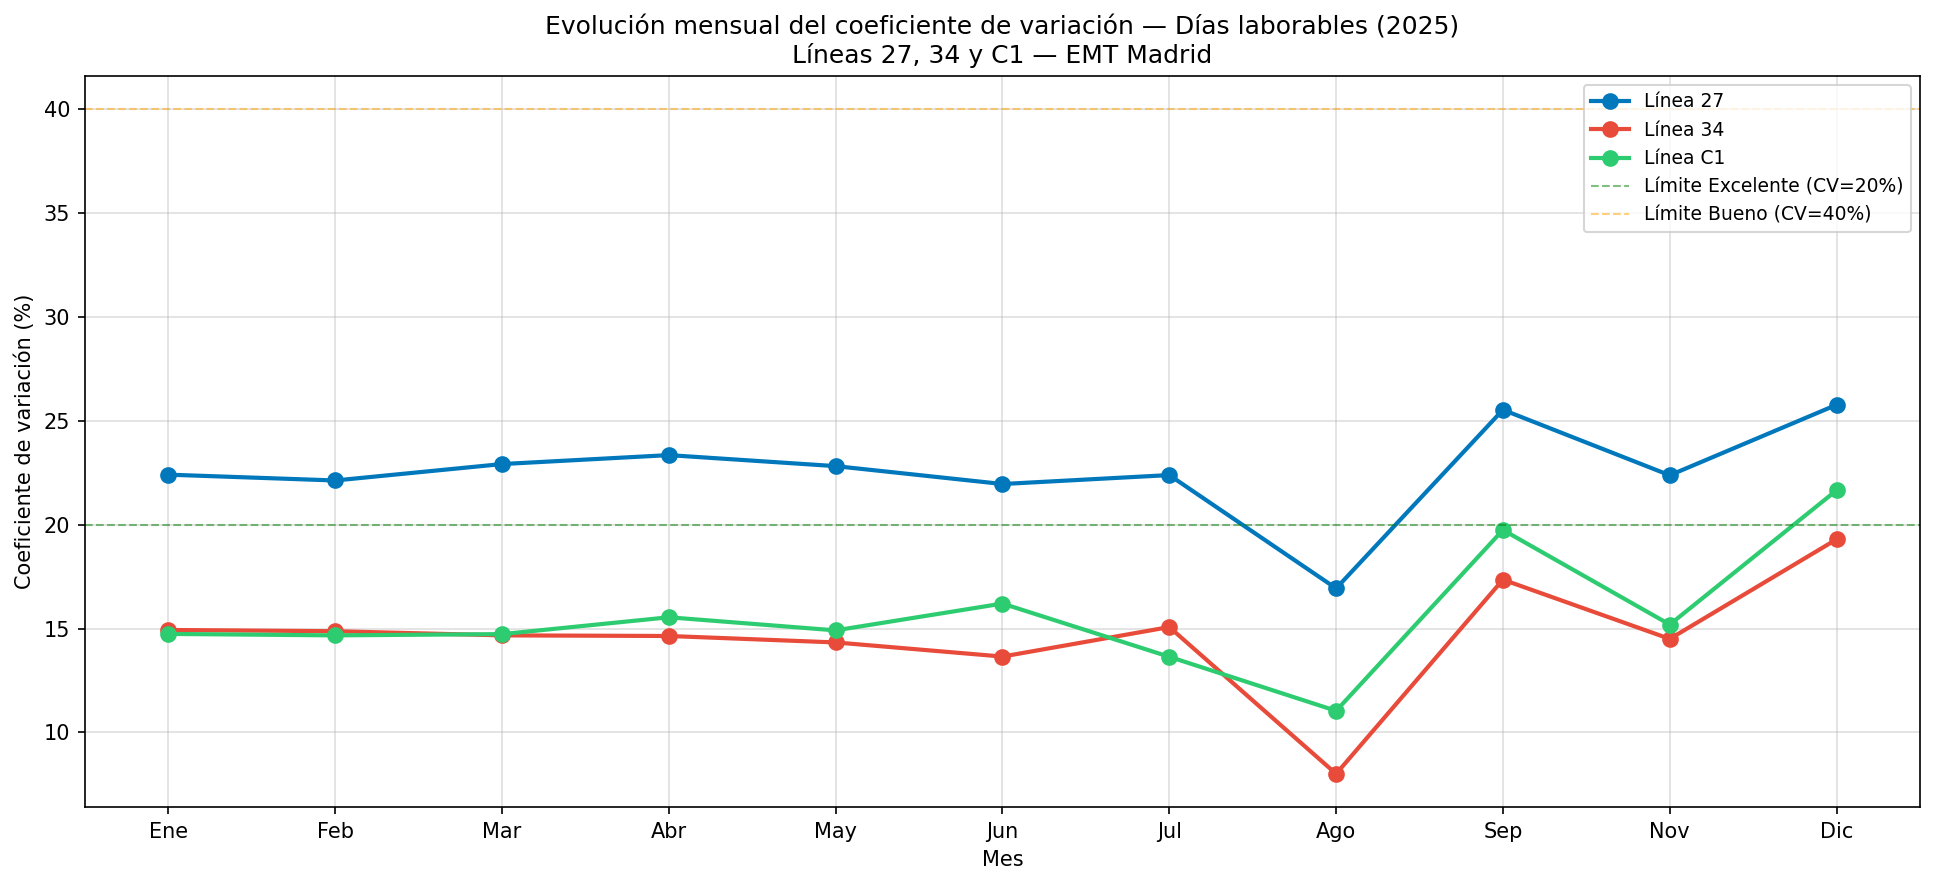

Gráfico 5 guardado


In [30]:
# Gráfico 5: Evolución mensual del CV (días laborables)

# Calculamos el CV mensual por línea para días laborables
oferta_LA = oferta_analisis[oferta_analisis['TIPODIAMO'] == 'LA'].copy()

cv_mensual = oferta_LA.groupby(['nombre_linea', 'mes'])['NumCCReal'].agg(
    media='mean',
    std='std'
).reset_index()

cv_mensual['cv'] = (cv_mensual['std'] / cv_mensual['media'] * 100).round(2)

meses_etiquetas = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 11: 'Nov', 12: 'Dic'
}

fig, ax = plt.subplots(figsize=(13, 6))

for linea in lineas:
    datos = cv_mensual[cv_mensual['nombre_linea'] == linea].sort_values('mes')
    ax.plot(
        datos['mes'].map(meses_etiquetas),
        datos['cv'],
        marker='o',
        linewidth=2,
        markersize=7,
        label=linea,
        color=colores_lineas[linea]
    )

ax.axhline(y=20, color='green', linestyle='--',
           alpha=0.5, linewidth=1, label='Límite Excelente (CV=20%)')
ax.axhline(y=40, color='orange', linestyle='--',
           alpha=0.5, linewidth=1, label='Límite Bueno (CV=40%)')

ax.set_xlabel('Mes')
ax.set_ylabel('Coeficiente de variación (%)')
ax.set_title('Evolución mensual del coeficiente de variación — Días laborables (2025)\nLíneas 27, 34 y C1 — EMT Madrid')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico5_cv_mensual.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 5 guardado")

In [ ]:
# PARTE 4: ANALISIS DE DEMANDA DE VIAJEROS 2025

In [31]:
#  Cargar datos de demanda

# Cargamos el fichero de demanda diaria de viajeros
DEMANDA = BASE + '/03_demanda_viajeros'

fichero_demanda = os.listdir(DEMANDA)[0]
print(f"Cargando: {fichero_demanda}")

demanda = pd.read_csv(f"{DEMANDA}/{fichero_demanda}", sep=';', encoding='latin1')

print(f"\nFilas: {len(demanda):,}")
print(f"Columnas: {demanda.columns.tolist()}")
print(f"\nPrimeras filas:")
print(demanda.head(5))
print(f"\nTipos de datos:")
print(demanda.dtypes)

Cargando: demandadialinea_2025.csv

Filas: 83,169
Columnas: ['ï»¿Fecha', 'Linea', 'TotalViajeros']

Primeras filas:
     ï»¿Fecha  Linea  TotalViajeros
0  2025-01-01      1           2359
1  2025-01-01      2           3346
2  2025-01-01      3           2446
3  2025-01-01      4           1980
4  2025-01-01      5           1808

Tipos de datos:
ï»¿Fecha         object
Linea             int64
TotalViajeros     int64
dtype: object


In [32]:
# Inspección y limpieza

# Inspeccionamos valores únicos clave
print("Valores únicos en columna Linea (muestra):")
print(sorted(demanda.iloc[:, 1].astype(str).unique())[:20])

print(f"\nRango de fechas:")
print(f"  Mínimo: {demanda.iloc[:, 0].min()}")
print(f"  Máximo: {demanda.iloc[:, 0].max()}")

print(f"\nEstadísticas básicas:")
print(demanda.describe())

Valores únicos en columna Linea (muestra):
['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '11', '110', '111', '112', '113', '114', '115', '116']

Rango de fechas:
  Mínimo: 2025-01-01
  Máximo: 2025-12-31

Estadísticas básicas:
              Linea  TotalViajeros
count  83169.000000   83169.000000
mean     210.616095    6157.170508
std      219.235541    7410.592271
min        1.000000       4.000000
25%       58.000000    1527.000000
50%      126.000000    4467.000000
75%      361.000000    8599.000000
max      898.000000  137028.000000


In [34]:
# Inspección y limpieza CORREGIDA

# Renombramos la columna de fecha que tiene problema de codificación
demanda.columns = ['Fecha', 'Linea', 'TotalViajeros']

print("Columnas corregidas:", demanda.columns.tolist())
print(f"\nRango de fechas:")
print(f"  Mínimo: {demanda['Fecha'].min()}")
print(f"  Máximo: {demanda['Fecha'].max()}")

print(f"\nLíneas únicas disponibles (muestra):")
print(sorted(demanda['Linea'].unique())[:30])

print(f"\nEstadísticas básicas de TotalViajeros:")
print(demanda['TotalViajeros'].describe())

Columnas corregidas: ['Fecha', 'Linea', 'TotalViajeros']

Rango de fechas:
  Mínimo: 2025-01-01
  Máximo: 2025-12-31

Líneas únicas disponibles (muestra):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]

Estadísticas básicas de TotalViajeros:
count     83169.000000
mean       6157.170508
std        7410.592271
min           4.000000
25%        1527.000000
50%        4467.000000
75%        8599.000000
max      137028.000000
Name: TotalViajeros, dtype: float64


In [35]:
#Filtrar líneas de estudio CORREGIDA


# Filtramos las tres líneas — C1 aparece como 68
demanda_lineas = demanda[demanda['Linea'].isin([27, 34, 68])].copy()

# Convertimos fecha
demanda_lineas['Fecha'] = pd.to_datetime(demanda_lineas['Fecha'])
demanda_lineas['mes']   = demanda_lineas['Fecha'].dt.month

# Asignamos nombre legible
def asignar_nombre_demanda(linea):
    if linea == 27:
        return 'Línea 27'
    elif linea == 34:
        return 'Línea 34'
    elif linea == 68:
        return 'Línea C1'
    return str(linea)

demanda_lineas['nombre_linea'] = (
    demanda_lineas['Linea'].apply(asignar_nombre_demanda)
)

print(f"Registros filtrados: {len(demanda_lineas):,}")
print()
print(demanda_lineas.groupby('nombre_linea')
      .agg(
          registros=('TotalViajeros', 'count'),
          total_viajeros=('TotalViajeros', 'sum'),
          media_diaria=('TotalViajeros', 'mean')
      )
      .round(0)
      .reset_index()
      .to_string(index=False))

Registros filtrados: 1,095

nombre_linea  registros  total_viajeros  media_diaria
    Línea 27        365         7123430       19516.0
    Línea 34        365        10332433       28308.0
    Línea C1        365         7593060       20803.0


In [37]:
#  Calcular viajeros totales y medios por línea y mes
# Agrupamos por línea y mes
demanda_mensual = demanda_lineas.groupby(
    ['nombre_linea', 'mes']
)['TotalViajeros'].agg(
    total_viajeros='sum',
    media_diaria='mean',
    num_dias='count'
).reset_index()

demanda_mensual['total_viajeros'] = demanda_mensual['total_viajeros'].round(0)
demanda_mensual['media_diaria']   = demanda_mensual['media_diaria'].round(0)

print("Viajeros totales por línea y mes (2025):")
print()
for linea in ['Línea 27', 'Línea 34', 'Línea C1']:
    datos = demanda_mensual[demanda_mensual['nombre_linea'] == linea]
    total_anual = datos['total_viajeros'].sum()
    print(f"{linea} — Total anual: {total_anual:,.0f} viajeros")
    print(datos[['mes', 'total_viajeros', 'media_diaria']].to_string(index=False))
    print()

Viajeros totales por línea y mes (2025):

Línea 27 — Total anual: 7,123,430 viajeros
 mes  total_viajeros  media_diaria
   1          587531       18953.0
   2          603069       21538.0
   3          622346       20076.0
   4          590619       19687.0
   5          617371       19915.0
   6          620861       20695.0
   7          580534       18727.0
   8          360250       11621.0
   9          621073       20702.0
  10          685859       22124.0
  11          627720       20924.0
  12          606197       19555.0

Línea 34 — Total anual: 10,332,433 viajeros
 mes  total_viajeros  media_diaria
   1          877049       28292.0
   2          886044       31644.0
   3          929372       29980.0
   4          850514       28350.0
   5          932630       30085.0
   6          913612       30454.0
   7          805327       25978.0
   8          578427       18659.0
   9          877121       29237.0
  10          979677       31602.0
  11          868520       289

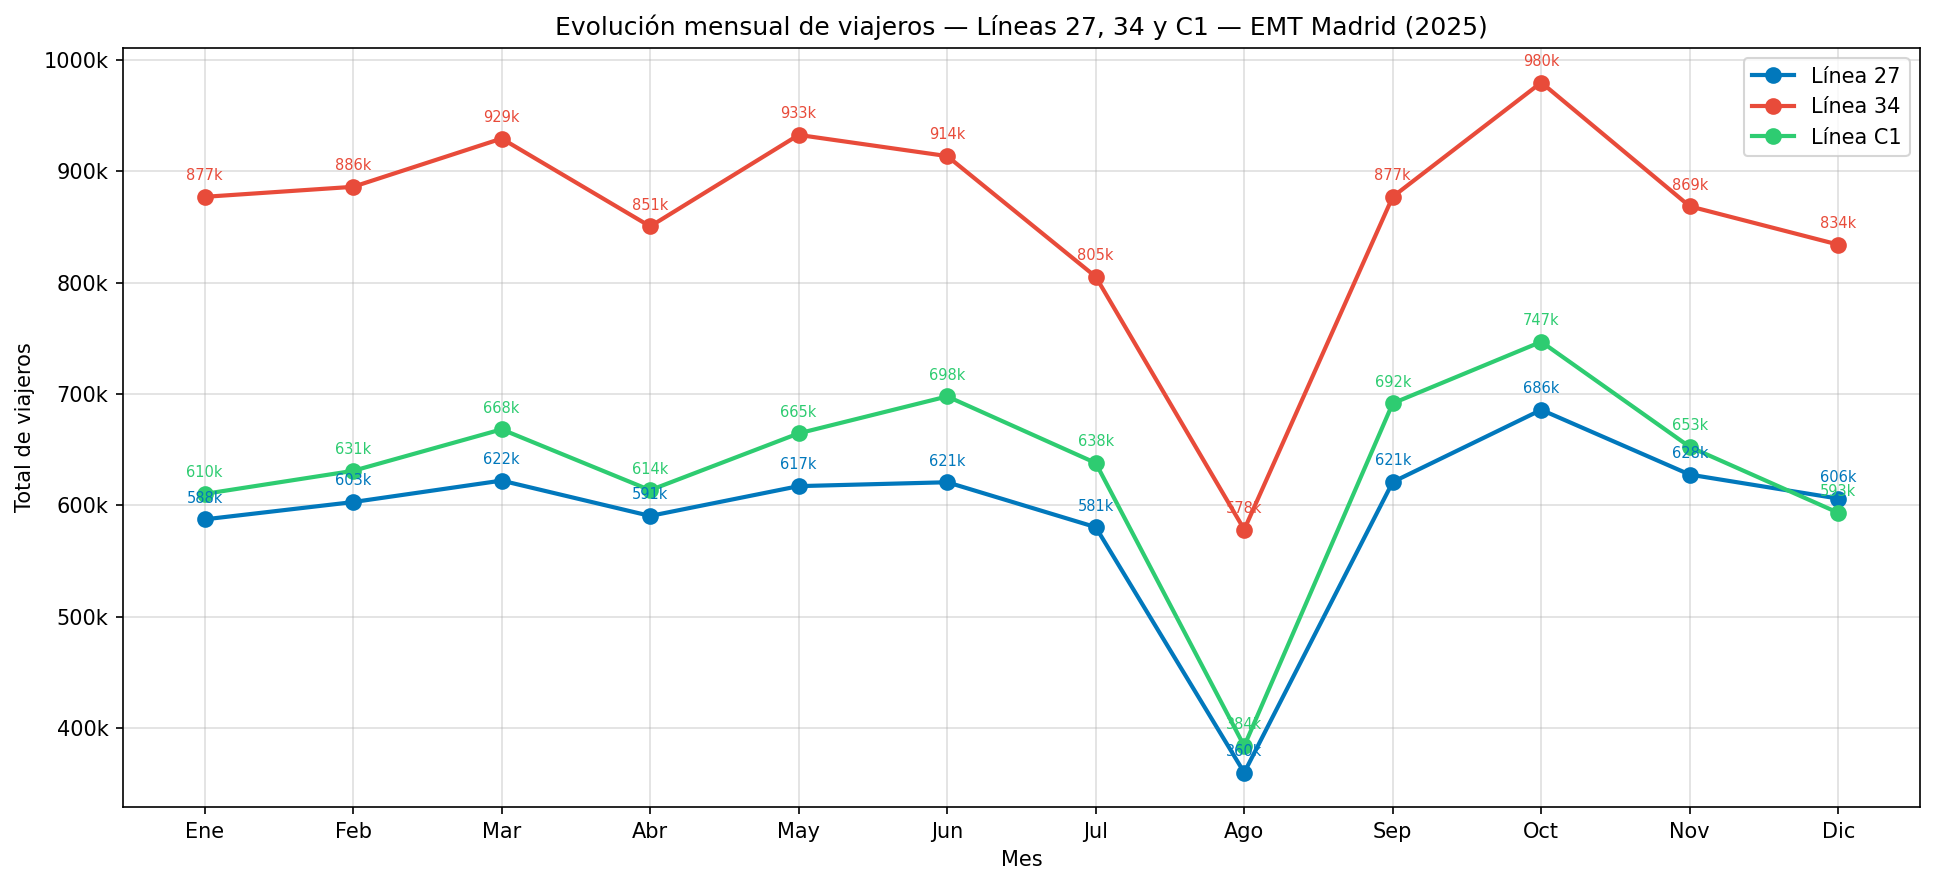

Gráfico 6 guardado


In [38]:
# Gráfico 6: Evolución mensual de viajeros

meses_etiquetas = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}

fig, ax = plt.subplots(figsize=(13, 6))

for linea in ['Línea 27', 'Línea 34', 'Línea C1']:
    datos = demanda_mensual[
        demanda_mensual['nombre_linea'] == linea
    ].sort_values('mes')

    ax.plot(
        datos['mes'].map(meses_etiquetas),
        datos['total_viajeros'],
        marker='o',
        linewidth=2,
        markersize=7,
        label=linea,
        color=colores_lineas[linea]
    )

    for _, row in datos.iterrows():
        ax.annotate(
            f"{row['total_viajeros']/1000:.0f}k",
            (meses_etiquetas[row['mes']], row['total_viajeros']),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=7,
            color=colores_lineas[linea]
        )

ax.set_xlabel('Mes')
ax.set_ylabel('Total de viajeros')
ax.set_title(
    'Evolución mensual de viajeros — Líneas 27, 34 y C1 — EMT Madrid (2025)'
)
ax.legend(loc='upper right')
ax.grid(alpha=0.4)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico6_viajeros_mensual.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 6 guardado")

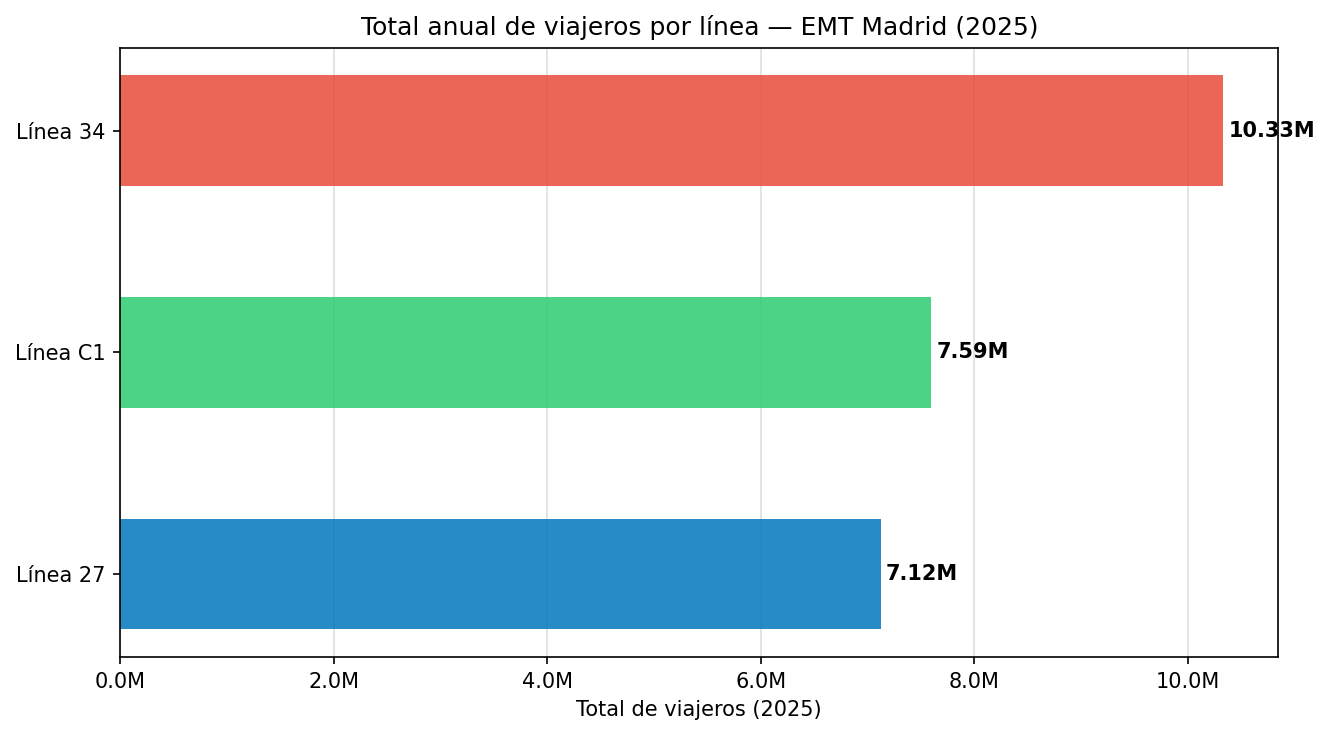

Gráfico 7 guardado


In [39]:
# Gráfico 7: Total anual de viajeros por línea

# Total anual por línea
total_anual = demanda_lineas.groupby(
    'nombre_linea'
)['TotalViajeros'].sum().reset_index()

total_anual.columns = ['nombre_linea', 'total_viajeros']
total_anual = total_anual.sort_values('total_viajeros', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    total_anual['nombre_linea'],
    total_anual['total_viajeros'],
    color=[colores_lineas[l] for l in total_anual['nombre_linea']],
    alpha=0.85,
    height=0.5
)

for barra, val in zip(barras, total_anual['total_viajeros']):
    ax.text(
        val + 50000,
        barra.get_y() + barra.get_height() / 2,
        f'{val/1e6:.2f}M',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('Total de viajeros (2025)')
ax.set_title(
    'Total anual de viajeros por línea — EMT Madrid (2025)'
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
ax.grid(axis='x', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico7_total_viajeros_anual.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 7 guardado")

In [40]:
# Guardar datos de demanda procesados

demanda_mensual.to_csv(
    f"{OUTPUT}/demanda_mensual_2025.csv",
    index=False,
    encoding='utf-8-sig'
)

demanda_lineas.to_csv(
    f"{OUTPUT}/demanda_filtrada_2025.csv",
    index=False,
    encoding='utf-8-sig'
)

print("Ficheros guardados correctamente:")
print(f"  demanda_mensual_2025.csv   →  {len(demanda_mensual)} filas")
print(f"  demanda_filtrada_2025.csv  →  {len(demanda_lineas):,} filas")

print("\nResumen de ficheros generados en el proyecto:")
for f in sorted(os.listdir(OUTPUT)):
    print(f"  {f}")

Ficheros guardados correctamente:
  demanda_mensual_2025.csv   →  36 filas
  demanda_filtrada_2025.csv  →  1,095 filas

Resumen de ficheros generados en el proyecto:
  demanda_filtrada_2025.csv
  demanda_mensual_2025.csv
  grafico1_media_autobuses_LA.png
  grafico2_cv_LA.png
  grafico3_cv_por_tipo_dia.png
  grafico4_boxplot_LA.png
  grafico5_cv_mensual.png
  grafico6_viajeros_mensual.png
  grafico7_total_viajeros_anual.png
  indicadores_reales_2025.csv
  oferta_filtrada_2025.csv


In [ ]:
# PARTE 5 : ANALISIS ADICIONALES

In [41]:
# Tabla resumen consolidada de indicadores (días laborables)

# Tabla resumen consolidada para días laborables
# combinando indicadores de las tres líneas

resumen_final = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
].copy()

# Etiquetas legibles para los tramos
resumen_final['tramo_horario'] = resumen_final['tramo_horario'].map({
    '1_Punta_manana (7-9h)':   'Punta mañana (7-9h)',
    '2_Mediodia (9-14h)':      'Mediodía (9-14h)',
    '3_Punta_tarde (14-16h)':  'Punta tarde (14-16h)',
    '4_Tarde (16-20h)':        'Tarde (16-20h)',
    '5_Noche (20-23h)':        'Noche (20-23h)'
})

# Seleccionamos y renombramos columnas
tabla_resumen = resumen_final[[
    'nombre_linea', 'tramo_horario', 'media',
    'desviacion_tipica', 'cv', 'minimo', 'maximo',
    'num_observaciones', 'nivel_servicio'
]].rename(columns={
    'nombre_linea':      'Línea',
    'tramo_horario':     'Tramo horario',
    'media':             'Media autobuses',
    'desviacion_tipica': 'Desv. típica',
    'cv':                'CV (%)',
    'minimo':            'Mínimo',
    'maximo':            'Máximo',
    'num_observaciones': 'Observaciones',
    'nivel_servicio':    'Nivel de servicio'
})

# Guardamos como CSV
tabla_resumen.to_csv(
    f"{OUTPUT}/tabla_resumen_indicadores_LA.csv",
    index=False,
    encoding='utf-8-sig'
)

print("TABLA RESUMEN — INDICADORES DÍAS LABORABLES 2025")
print("=" * 90)
print(tabla_resumen.to_string(index=False))
print(f"\nFichero guardado: tabla_resumen_indicadores_LA.csv")

TABLA RESUMEN — INDICADORES DÍAS LABORABLES 2025
   Línea        Tramo horario  Media autobuses  Desv. típica  CV (%)  Mínimo  Máximo  Observaciones      Nivel de servicio
Línea 27  Punta mañana (7-9h)            21.65          3.64   16.83      11      24            452   Excelente (CV < 20%)
Línea 27     Mediodía (9-14h)            16.26          3.80   23.36       8      24           1130 Bueno (20% ≤ CV < 40%)
Línea 27 Punta tarde (14-16h)            14.93          2.15   14.40       9      17            452   Excelente (CV < 20%)
Línea 27       Tarde (16-20h)            14.83          2.38   16.06       8      17            904   Excelente (CV < 20%)
Línea 27       Noche (20-23h)            11.69          3.12   26.66       3      17            677 Bueno (20% ≤ CV < 40%)
Línea 34  Punta mañana (7-9h)            20.50          3.22   15.71      11      24            452   Excelente (CV < 20%)
Línea 34     Mediodía (9-14h)            19.28          2.96   15.38      11      24      

Cruce demanda — variabilidad:
nombre_linea  cv_medio  total_viajeros
    Línea 27     19.46         7123430
    Línea 34     16.83        10332433
    Línea C1     19.68         7593060


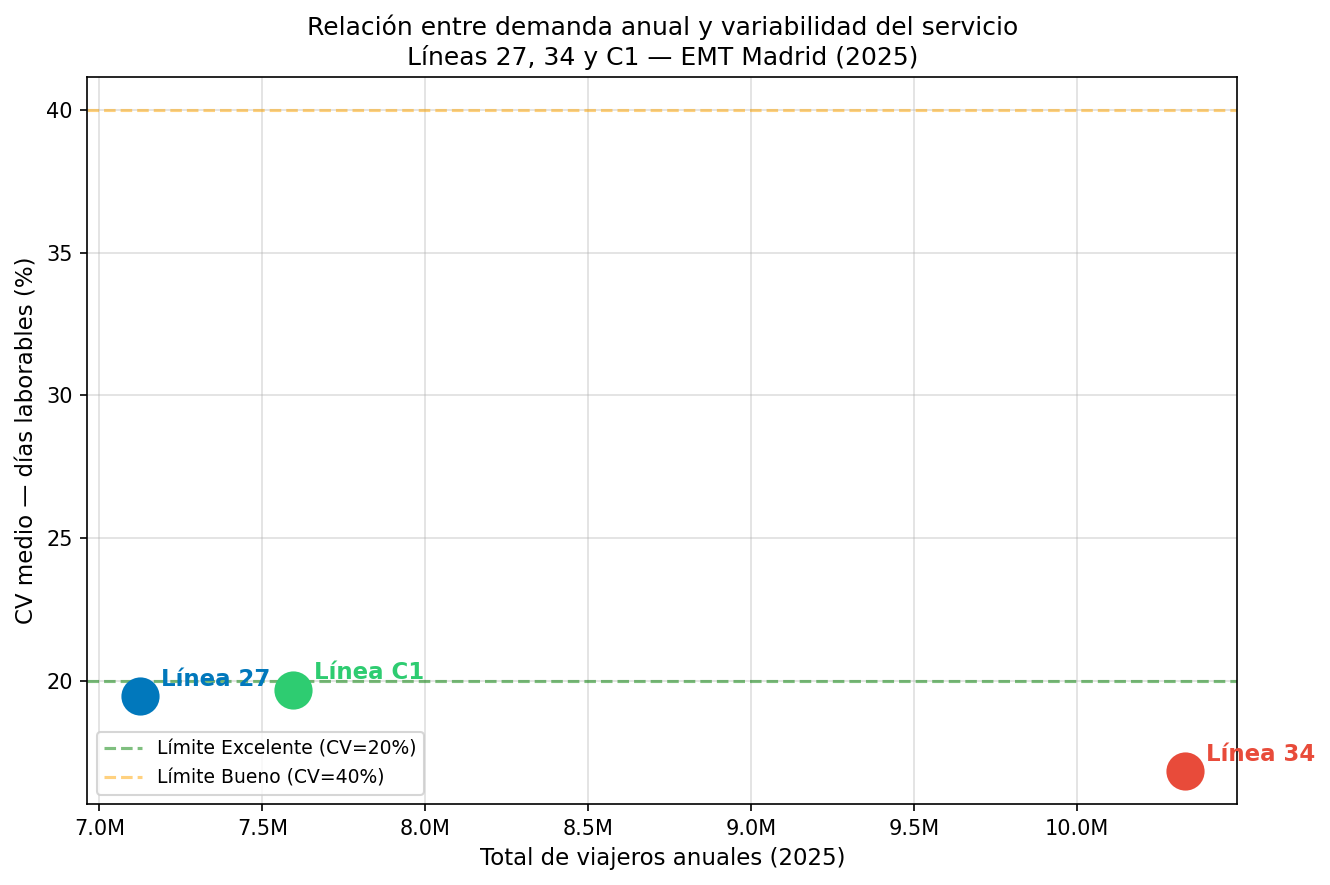

Gráfico 8 guardado


In [43]:
# Gráfico 8: Relación entre demanda y variabilidad (CV)

# Cruzamos demanda total anual con CV medio por línea
# para días laborables

# CV medio por línea (promedio de todos los tramos laborables)
cv_medio_linea = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
].groupby('nombre_linea')['cv'].mean().round(2).reset_index()
cv_medio_linea.columns = ['nombre_linea', 'cv_medio']

# Demanda total anual por línea
demanda_total = demanda_lineas.groupby(
    'nombre_linea'
)['TotalViajeros'].sum().reset_index()
demanda_total.columns = ['nombre_linea', 'total_viajeros']

# Unimos ambos dataframes
cruce = cv_medio_linea.merge(demanda_total, on='nombre_linea')

print("Cruce demanda — variabilidad:")
print(cruce.to_string(index=False))

# Gráfico de dispersión
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in cruce.iterrows():
    ax.scatter(
        row['total_viajeros'],
        row['cv_medio'],
        color=colores_lineas[row['nombre_linea']],
        s=300,
        zorder=5
    )
    ax.annotate(
        row['nombre_linea'],
        (row['total_viajeros'], row['cv_medio']),
        textcoords='offset points',
        xytext=(10, 5),
        fontsize=11,
        fontweight='bold',
        color=colores_lineas[row['nombre_linea']]
    )

# Líneas de referencia de niveles de servicio
ax.axhline(y=20, color='green', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Límite Excelente (CV=20%)')
ax.axhline(y=40, color='orange', linestyle='--',
           alpha=0.5, linewidth=1.5, label='Límite Bueno (CV=40%)')

ax.set_xlabel('Total de viajeros anuales (2025)', fontsize=11)
ax.set_ylabel('CV medio — días laborables (%)', fontsize=11)
ax.set_title(
    'Relación entre demanda anual y variabilidad del servicio\n'
    'Líneas 27, 34 y C1 — EMT Madrid (2025)',
    fontsize=12
)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico8_demanda_vs_cv.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 8 guardado")

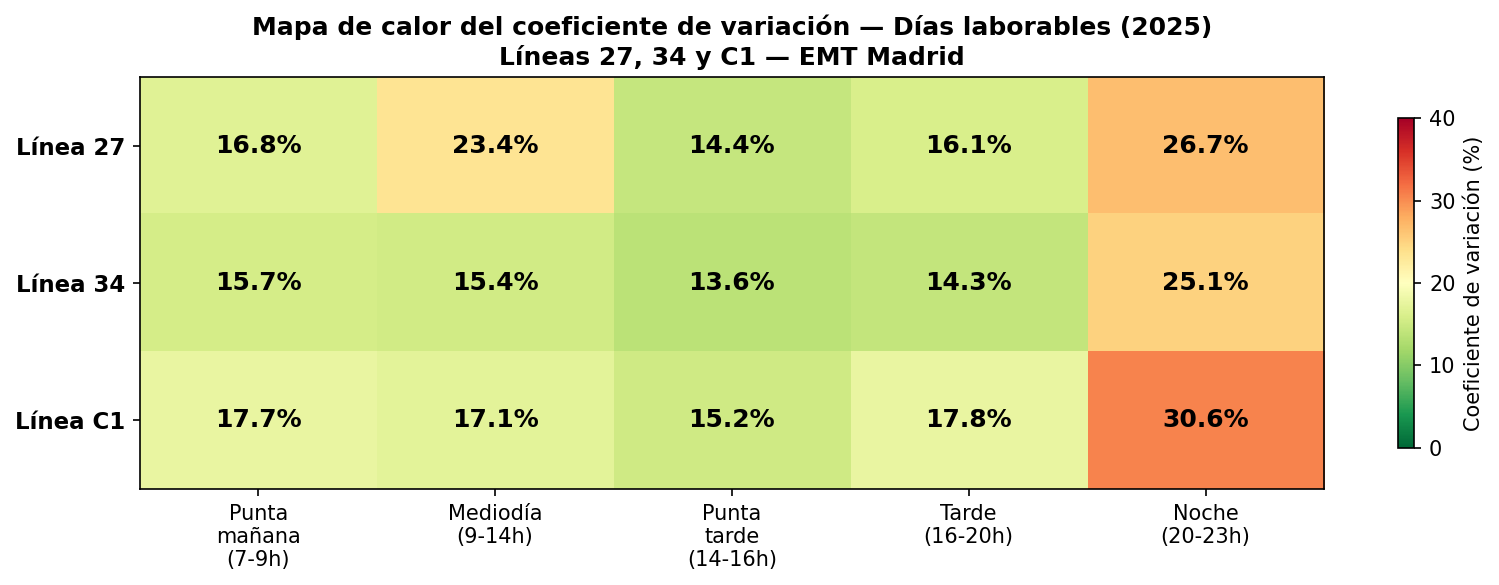

Gráfico 9 guardado


In [44]:
# Gráfico 9: Mapa de calor de CV por línea y tramo horario


import matplotlib.colors as mcolors

# Preparamos datos para el mapa de calor
# Solo días laborables
pivot_cv = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
].pivot_table(
    index='nombre_linea',
    columns='tramo_horario',
    values='cv'
)

# Reordenamos columnas
pivot_cv = pivot_cv[orden_tramos]

# Renombramos columnas para el gráfico
pivot_cv.columns = [
    'Punta\nmañana\n(7-9h)',
    'Mediodía\n(9-14h)',
    'Punta\ntarde\n(14-16h)',
    'Tarde\n(16-20h)',
    'Noche\n(20-23h)'
]

fig, ax = plt.subplots(figsize=(11, 4))

# Mapa de color: verde (bajo CV) → rojo (alto CV)
cmap = plt.cm.RdYlGn_r
im = ax.imshow(pivot_cv.values, cmap=cmap, aspect='auto',
               vmin=0, vmax=40)

# Etiquetas de ejes
ax.set_xticks(range(len(pivot_cv.columns)))
ax.set_xticklabels(pivot_cv.columns, fontsize=10)
ax.set_yticks(range(len(pivot_cv.index)))
ax.set_yticklabels(pivot_cv.index, fontsize=11, fontweight='bold')

# Valores dentro de cada celda
for i in range(len(pivot_cv.index)):
    for j in range(len(pivot_cv.columns)):
        val = pivot_cv.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%',
                    ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='black')

# Barra de color
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Coeficiente de variación (%)', fontsize=10)

ax.set_title(
    'Mapa de calor del coeficiente de variación — Días laborables (2025)\n'
    'Líneas 27, 34 y C1 — EMT Madrid',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico9_heatmap_cv.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 9 guardado")

In [45]:
# Resumen final de todos los ficheros generados

print("=" * 60)
print("RESUMEN FINAL — FICHEROS GENERADOS EN EL PROYECTO")
print("=" * 60)

ficheros_output = sorted(os.listdir(OUTPUT))

csvs    = [f for f in ficheros_output if f.endswith('.csv')]
graficos = [f for f in ficheros_output if f.endswith('.png')]

print(f"\nFicheros de datos ({len(csvs)}):")
for f in csvs:
    print(f"  {f}")

print(f"\nGráficos ({len(graficos)}):")
for f in graficos:
    print(f"  {f}")

print(f"\nTotal de ficheros: {len(ficheros_output)}")
print("\nAnálisis completado correctamente.")

RESUMEN FINAL — FICHEROS GENERADOS EN EL PROYECTO

Ficheros de datos (5):
  demanda_filtrada_2025.csv
  demanda_mensual_2025.csv
  indicadores_reales_2025.csv
  oferta_filtrada_2025.csv
  tabla_resumen_indicadores_LA.csv

Gráficos (9):
  grafico1_media_autobuses_LA.png
  grafico2_cv_LA.png
  grafico3_cv_por_tipo_dia.png
  grafico4_boxplot_LA.png
  grafico5_cv_mensual.png
  grafico6_viajeros_mensual.png
  grafico7_total_viajeros_anual.png
  grafico8_demanda_vs_cv.png
  grafico9_heatmap_cv.png

Total de ficheros: 14

Análisis completado correctamente.


In [ ]:
# PARTE 6: Análisis descriptivo del GTFS — Planificación teórica del servicio

In [46]:
# Cargar ficheros GTFS necesarios

# Cargamos los ficheros GTFS relevantes
routes      = pd.read_csv(f"{GTFS}/routes.txt")
trips       = pd.read_csv(f"{GTFS}/trips.txt")
frequencies = pd.read_csv(f"{GTFS}/frequencies.txt")
stops_times = pd.read_csv(f"{GTFS}/stop_times.txt")
stops       = pd.read_csv(f"{GTFS}/stops.txt")
calendar    = pd.read_csv(f"{GTFS}/calendar.txt")

print("Ficheros GTFS cargados:")
print(f"  routes.txt:      {len(routes):>6} filas")
print(f"  trips.txt:       {len(trips):>6} filas")
print(f"  frequencies.txt: {len(frequencies):>6} filas")
print(f"  stop_times.txt:  {len(stops_times):>6} filas")
print(f"  stops.txt:       {len(stops):>6} filas")
print(f"  calendar.txt:    {len(calendar):>6} filas")

Ficheros GTFS cargados:
  routes.txt:         236 filas
  trips.txt:        87068 filas
  frequencies.txt:  87068 filas
  stop_times.txt:  2232038 filas
  stops.txt:         4912 filas
  calendar.txt:         5 filas


In [48]:
# Identificar las líneas de estudio en el GTFS

# Identificamos las tres líneas en el GTFS
route_ids = {
    'Línea 27': 27,
    'Línea 34': 34,
    'Línea C1': 68
}

# Filtramos trips de las líneas de estudio
trips_lineas = trips[trips['route_id'].isin(route_ids.values())].copy()

# Añadimos nombre legible
id_a_nombre = {v: k for k, v in route_ids.items()}
trips_lineas['nombre_linea'] = trips_lineas['route_id'].map(id_a_nombre)

print("Viajes por línea, tipo de día y sentido:")
print()
print(trips_lineas.groupby(['nombre_linea', 'service_id', 'direction_id'])
      .size()
      .reset_index(name='num_viajes')
      .to_string(index=False))

print(f"\nTotal de viajes en las 3 líneas: {len(trips_lineas):,}")

Viajes por línea, tipo de día y sentido:

nombre_linea service_id  direction_id  num_viajes
    Línea 27         FE             0          79
    Línea 27         FE             1          78
    Línea 27         LA             0         193
    Línea 27         LA             1         194
    Línea 27         SA             0          88
    Línea 27         SA             1          89
    Línea 34         FE             0          78
    Línea 34         FE             1          78
    Línea 34         LA             0         155
    Línea 34         LA             1         155
    Línea 34         SA             0          95
    Línea 34         SA             1          95
    Línea C1         FE             0          90
    Línea C1         FE             1          88
    Línea C1         LA             0         198
    Línea C1         LA             1         196
    Línea C1         SA             0         117
    Línea C1         SA             1         114

Total d

In [60]:
# Extraer headways planificados por tramo horario (corregida)

freq_lineas['headway_min'] = (freq_lineas['headway_secs'] / 60).round(2)

def hora_a_numero(hora_str):
    partes = str(hora_str).split(':')
    return int(partes[0]) + int(partes[1]) / 60

freq_lineas['hora_inicio'] = freq_lineas['start_time'].apply(hora_a_numero)
freq_lineas['hora_fin']    = freq_lineas['end_time'].apply(hora_a_numero)

tramos_analisis = [
    ('1_Punta_manana (7-9h)',   7,  9),
    ('2_Mediodia (9-14h)',      9,  14),
    ('3_Punta_tarde (14-16h)', 14, 16),
    ('4_Tarde (16-20h)',       16, 20),
    ('5_Noche (20-23h)',       20, 23),
]

registros = []

for _, row in freq_lineas[freq_lineas['service_id'] == 'LA'].iterrows():
    h_ini = row['hora_inicio']
    h_fin = row['hora_fin']

    for nombre_tramo, t_ini, t_fin in tramos_analisis:
        solapamiento_ini = max(h_ini, t_ini)
        solapamiento_fin = min(h_fin, t_fin)

        if solapamiento_ini < solapamiento_fin:
            registros.append({
                'nombre_linea':    row['nombre_linea'],
                'service_id':      row['service_id'],
                'direction_id':    row['direction_id'],
                'tramo_horario':   nombre_tramo,
                'headway_min':     row['headway_min'],
                'horas_cubiertas': solapamiento_fin - solapamiento_ini
            })

freq_analisis_v2 = pd.DataFrame(registros)

print(f"Registros generados: {len(freq_analisis_v2)}")

# Headway ponderado por horas cubiertas
tabla_gtfs_v2 = freq_analisis_v2.groupby(
    ['nombre_linea', 'tramo_horario']
).apply(
    lambda x: pd.Series({
        'headway_planif_min': (
            x['headway_min'] * x['horas_cubiertas']
        ).sum() / x['horas_cubiertas'].sum()
    })
).reset_index()

tabla_gtfs_v2['headway_planif_min'] = tabla_gtfs_v2['headway_planif_min'].round(2)
tabla_gtfs_v2['frec_teorica_exp_hora'] = (
    60 / tabla_gtfs_v2['headway_planif_min']
).round(2)

mapa_tramos = {
    '1_Punta_manana (7-9h)':   'Punta mañana (7-9h)',
    '2_Mediodia (9-14h)':      'Mediodía (9-14h)',
    '3_Punta_tarde (14-16h)':  'Punta tarde (14-16h)',
    '4_Tarde (16-20h)':        'Tarde (16-20h)',
    '5_Noche (20-23h)':        'Noche (20-23h)'
}

tabla_gtfs_v2['tramo_horario'] = tabla_gtfs_v2['tramo_horario'].map(mapa_tramos)

print()
print("PLANIFICACIÓN TEÓRICA — DÍAS LABORABLES")
print("=" * 70)
print(tabla_gtfs_v2.rename(columns={
    'nombre_linea':          'Línea',
    'tramo_horario':         'Tramo horario',
    'headway_planif_min':    'Headway planificado (min)',
    'frec_teorica_exp_hora': 'Frec. teórica (exp/h)'
}).to_string(index=False))

tabla_gtfs_v2.to_csv(
    f"{OUTPUT}/tabla_gtfs_planificacion_v2.csv",
    index=False,
    encoding='utf-8-sig'
)
print(f"\nFichero guardado: tabla_gtfs_planificacion_v2.csv")

Registros generados: 2126

PLANIFICACIÓN TEÓRICA — DÍAS LABORABLES
   Línea        Tramo horario  Headway planificado (min)  Frec. teórica (exp/h)
Línea 27  Punta mañana (7-9h)                       4.00                  15.00
Línea 27     Mediodía (9-14h)                       5.97                  10.05
Línea 27 Punta tarde (14-16h)                       6.00                  10.00
Línea 27       Tarde (16-20h)                       6.00                  10.00
Línea 27       Noche (20-23h)                       8.68                   6.91
Línea 34  Punta mañana (7-9h)                       6.51                   9.22
Línea 34     Mediodía (9-14h)                       7.04                   8.52
Línea 34 Punta tarde (14-16h)                       7.00                   8.57
Línea 34       Tarde (16-20h)                       7.00                   8.57
Línea 34       Noche (20-23h)                      10.71                   5.60
Línea C1  Punta mañana (7-9h)                       5

In [61]:
# Número de paradas por línea y sentido

paradas_linea = stops_times.merge(
    trips_lineas[['trip_id', 'nombre_linea', 'direction_id']],
    on='trip_id',
    how='inner'
)

resumen_paradas = paradas_linea.groupby(
    ['nombre_linea', 'direction_id']
)['stop_id'].nunique().reset_index()

resumen_paradas.columns = ['Línea', 'Sentido', 'Num_paradas']
resumen_paradas['Sentido'] = resumen_paradas['Sentido'].map(
    {0: 'Ida', 1: 'Vuelta'}
)

print("NÚMERO DE PARADAS POR LÍNEA Y SENTIDO:")
print()
print(resumen_paradas.to_string(index=False))

resumen_paradas.to_csv(
    f"{OUTPUT}/paradas_por_linea.csv",
    index=False,
    encoding='utf-8-sig'
)
print("\nFichero guardado: paradas_por_linea.csv")

NÚMERO DE PARADAS POR LÍNEA Y SENTIDO:

   Línea Sentido  Num_paradas
Línea 27     Ida           28
Línea 27  Vuelta           27
Línea 34     Ida           41
Línea 34  Vuelta           41
Línea C1     Ida           31
Línea C1  Vuelta           26

Fichero guardado: paradas_por_linea.csv


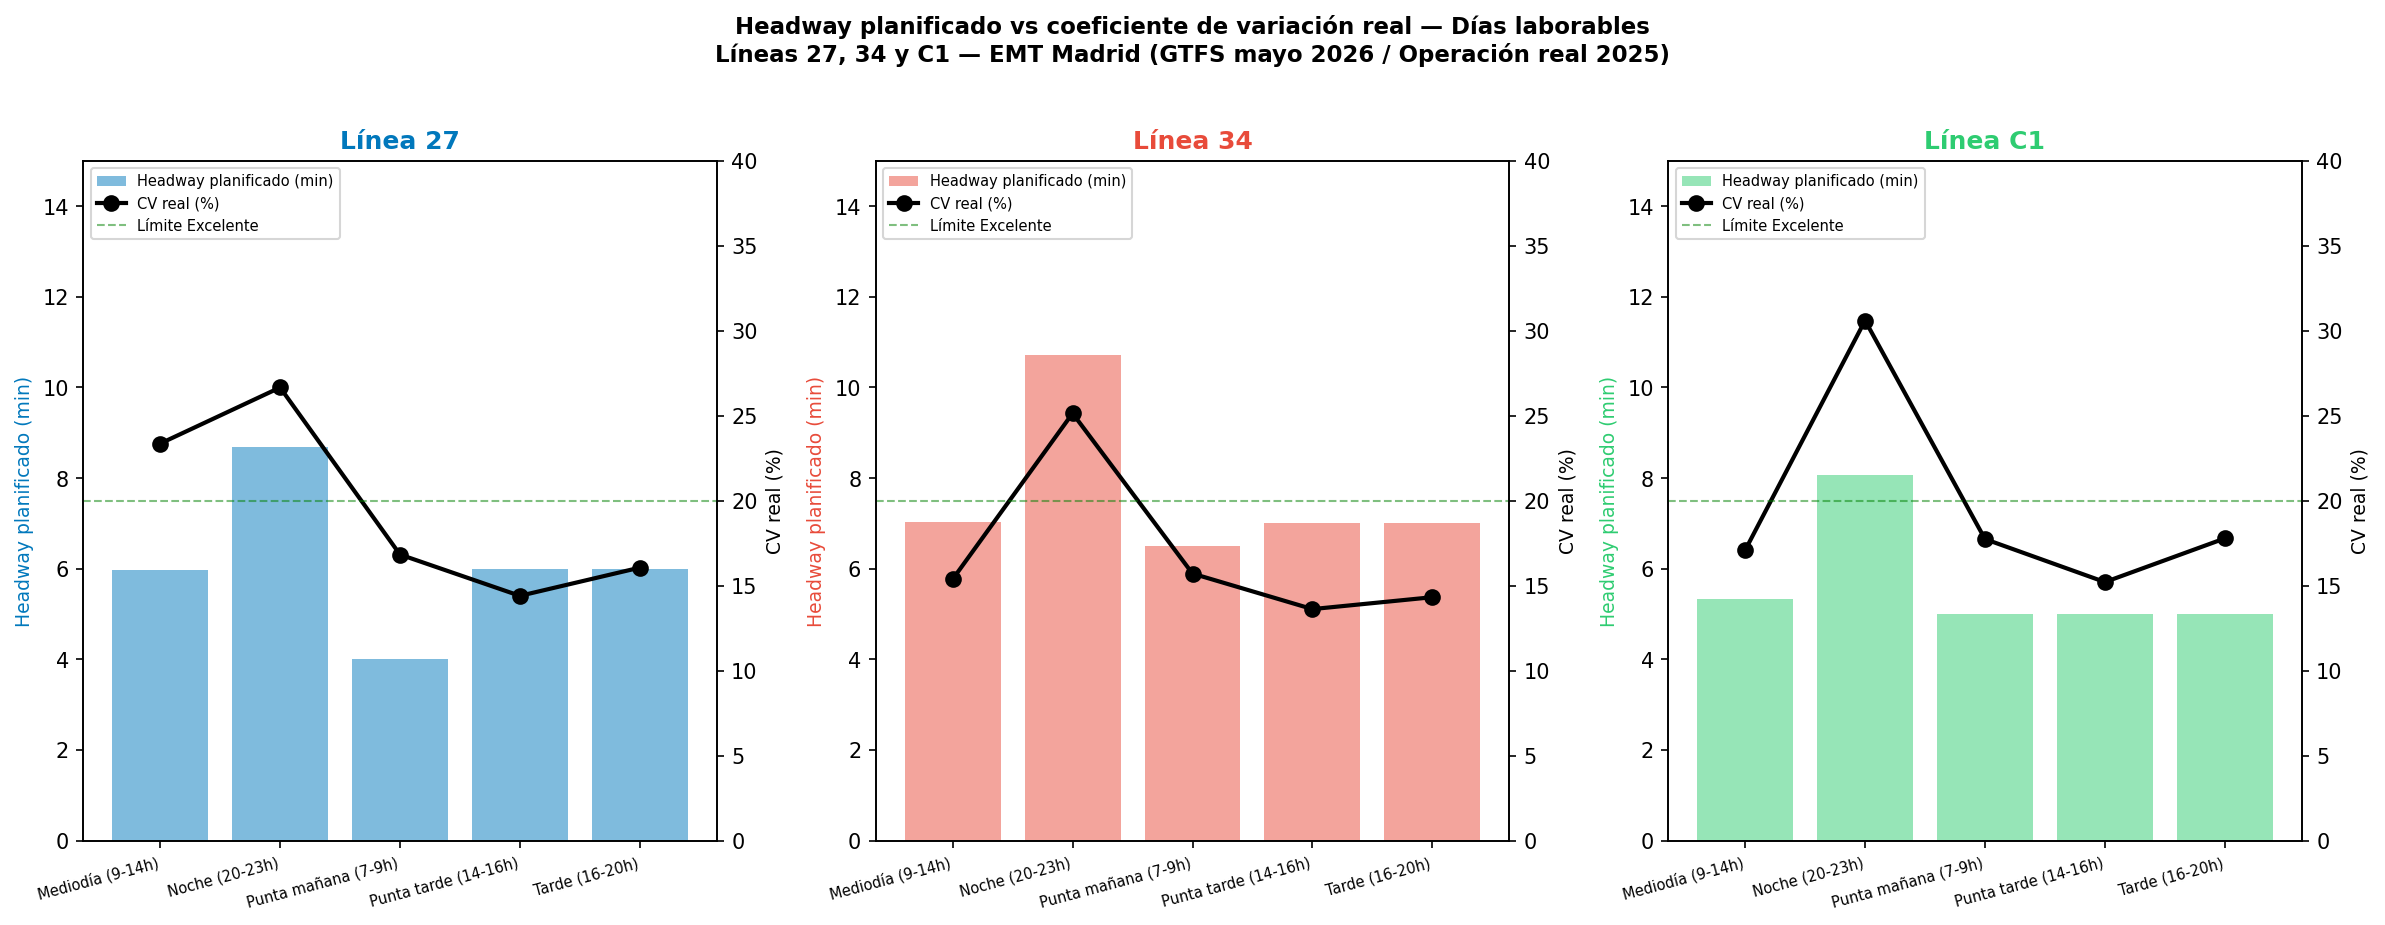

Gráfico 10 guardado


In [62]:
# Gráfico 10: Headway planificado vs CV real

comparativa = tabla_gtfs_v2.copy()

mapa_tramos_inverso = {v: k for k, v in mapa_tramos.items()}
comparativa['tramo_horario_key'] = comparativa['tramo_horario'].map(
    mapa_tramos_inverso
)

cv_plot = indicadores_reales[
    indicadores_reales['TIPODIAMO'] == 'LA'
][['nombre_linea', 'tramo_horario', 'cv']].copy()

comparativa = comparativa.merge(
    cv_plot,
    left_on=['nombre_linea', 'tramo_horario_key'],
    right_on=['nombre_linea', 'tramo_horario'],
    how='inner'
).rename(columns={'tramo_horario_x': 'tramo_horario'})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for idx, linea in enumerate(['Línea 27', 'Línea 34', 'Línea C1']):
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    datos = comparativa[
        comparativa['nombre_linea'] == linea
    ].sort_values('tramo_horario')

    etiquetas = list(datos['tramo_horario'])
    x = range(len(etiquetas))

    ax1.bar(
        x, datos['headway_planif_min'],
        color=colores_lineas[linea],
        alpha=0.5,
        label='Headway planificado (min)'
    )

    ax2.plot(
        x, datos['cv'],
        color='black',
        marker='o',
        linewidth=2,
        markersize=7,
        label='CV real (%)'
    )

    ax1.set_xticks(x)
    ax1.set_xticklabels(etiquetas, fontsize=7, rotation=15, ha='right')
    ax1.set_ylabel('Headway planificado (min)',
                   color=colores_lineas[linea], fontsize=9)
    ax2.set_ylabel('CV real (%)', color='black', fontsize=9)
    ax1.set_title(linea, fontweight='bold',
                  color=colores_lineas[linea])

    ax2.axhline(y=20, color='green', linestyle='--',
                alpha=0.5, linewidth=1, label='Límite Excelente')

    ax1.set_ylim(0, 15)
    ax2.set_ylim(0, 40)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               fontsize=7, loc='upper left')

fig.suptitle(
    'Headway planificado vs coeficiente de variación real — Días laborables\n'
    'Líneas 27, 34 y C1 — EMT Madrid (GTFS mayo 2026 / Operación real 2025)',
    fontsize=11, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/grafico10_headway_planif_vs_cv_real.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("Gráfico 10 guardado")

In [63]:
# Resumen final de todos los ficheros
print("=" * 60)
print("RESUMEN FINAL — FICHEROS GENERADOS EN EL PROYECTO")
print("=" * 60)

ficheros_output = sorted(os.listdir(OUTPUT))
csvs    = [f for f in ficheros_output if f.endswith('.csv')]
graficos = [f for f in ficheros_output if f.endswith('.png')]

print(f"\nFicheros de datos ({len(csvs)}):")
for f in csvs:
    print(f"  {f}")

print(f"\nGráficos ({len(graficos)}):")
for f in graficos:
    print(f"  {f}")

print(f"\nTotal de ficheros: {len(ficheros_output)}")
print("\nAnálisis completado correctamente.")


RESUMEN FINAL — FICHEROS GENERADOS EN EL PROYECTO

Ficheros de datos (9):
  demanda_filtrada_2025.csv
  demanda_mensual_2025.csv
  indicadores_reales_2025.csv
  oferta_filtrada_2025.csv
  paradas_por_linea.csv
  tabla_gtfs_planificacion.csv
  tabla_gtfs_planificacion_final.csv
  tabla_gtfs_planificacion_v2.csv
  tabla_resumen_indicadores_LA.csv

Gráficos (10):
  grafico10_headway_planif_vs_cv_real.png
  grafico1_media_autobuses_LA.png
  grafico2_cv_LA.png
  grafico3_cv_por_tipo_dia.png
  grafico4_boxplot_LA.png
  grafico5_cv_mensual.png
  grafico6_viajeros_mensual.png
  grafico7_total_viajeros_anual.png
  grafico8_demanda_vs_cv.png
  grafico9_heatmap_cv.png

Total de ficheros: 19

Análisis completado correctamente.


In [64]:
# Eliminamos ficheros duplicados de versiones anteriores
import os

ficheros_a_eliminar = [
    f"{OUTPUT}/tabla_gtfs_planificacion.csv",
    f"{OUTPUT}/tabla_gtfs_planificacion_final.csv"
]

for f in ficheros_a_eliminar:
    if os.path.exists(f):
        os.remove(f)
        print(f"Eliminado: {f}")
    else:
        print(f"No encontrado: {f}")

print("\nFicheros actuales en OUTPUT:")
for f in sorted(os.listdir(OUTPUT)):
    print(f"  {f}")

Eliminado: /content/drive/MyDrive/TFG_EMT/05_notebooks/tabla_gtfs_planificacion.csv
Eliminado: /content/drive/MyDrive/TFG_EMT/05_notebooks/tabla_gtfs_planificacion_final.csv

Ficheros actuales en OUTPUT:
  demanda_filtrada_2025.csv
  demanda_mensual_2025.csv
  grafico10_headway_planif_vs_cv_real.png
  grafico1_media_autobuses_LA.png
  grafico2_cv_LA.png
  grafico3_cv_por_tipo_dia.png
  grafico4_boxplot_LA.png
  grafico5_cv_mensual.png
  grafico6_viajeros_mensual.png
  grafico7_total_viajeros_anual.png
  grafico8_demanda_vs_cv.png
  grafico9_heatmap_cv.png
  indicadores_reales_2025.csv
  oferta_filtrada_2025.csv
  paradas_por_linea.csv
  tabla_gtfs_planificacion_v2.csv
  tabla_resumen_indicadores_LA.csv
